In [41]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

PATH1 = r'../data/raw/datasetextraido/'
nomes_mun = pd.read_csv('../data/datasets/municipio_tse_ibge.csv', sep=';', encoding='latin1')
dados = []
arquivos_processados = 0
total_contingencias = 0

for raiz, pastas, arquivos in os.walk(PATH1):
    for nome in arquivos:
        if nome.endswith('logd.dat'):
            caminho_completo = os.path.join(raiz, nome)
                      
            municipio = None
            zona = None
            secao = None
            tdvpe = []
            inicio_voto = None
            urna_contingencia = "Não"
            timeout_biometria = 0
            tecla_indevida = 0
            inatividade = 0
            sem_biometria = 0
            titulo_invalido = 0
            tempo_total_timeout = 0  # segundos perdidos em biometria
            tempo_total_inatividade = 0  # segundos perdidos em inatividade
            
            tdvpe_por_turno = {
               "1º Turno": {"antes_17": [], "depois_17": []}, 
               "2º Turno": {"antes_17": [], "depois_17": []}          
            }
            huv_por_turno = {"1º Turno": None, "2º Turno": None}
            turno_atual = "1º Turno"
         
            with open(caminho_completo, 'r', encoding='latin1', errors='replace') as arquivo_log:
                    for linha in arquivo_log:
                        texto_busca = linha.lower()
                       
                        if "urna de contingência" in texto_busca:
                           urna_contingencia = "Sim" 
                        if "iniciando aplicação" in texto_busca and "turno" in texto_busca:
                            if "1º turno" in texto_busca:
                                turno_atual = "1º Turno"
                            elif "2º turno" in texto_busca:
                                turno_atual = "2º Turno"

                        if "município" in texto_busca and municipio is None:
                            municipio = texto_busca.split("município")[1].replace(":", "").split()[0]
                        elif "zona eleitoral" in texto_busca and zona is None:
                            zona = texto_busca.split("zona eleitoral")[1].replace(":", "").split()[0]
                        elif "seção eleitoral" in texto_busca:
                            secao_nova = texto_busca.split("seção eleitoral")[1].replace(":", "").split()[0]
                          # Só atualiza se ainda não tem seção OU se a seção atual é "0000"
                          # (urna de contingência começa com 0000 e depois recebe a seção real)
                            if secao is None or secao in ('0', '00', '000', '0000'):
                                secao = secao_nova
                 
                        elif "eleitor foi habilitado" in texto_busca:
                            tempo_texto = linha[0:19]
                            inicio_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")
                            if inicio_biometria is not None and turno_atual == "1º Turno":
                              tempo_total_timeout += (inicio_voto - inicio_biometria).total_seconds()
                              inicio_biometria = None

                    
                        elif "o voto do eleitor foi computado" in texto_busca:
                            if inicio_voto is not None:
                                tempo_texto = linha[0:19]
                                fim_voto = datetime.strptime(tempo_texto, "%d/%m/%Y %H:%M:%S")
                                voto = (fim_voto - inicio_voto).total_seconds()
                                if fim_voto.hour < 17:
                                    tdvpe_por_turno[turno_atual]["antes_17"].append(voto)
                                else:
                                    tdvpe_por_turno[turno_atual]["depois_17"].append(voto)
                               
                                huv_por_turno[turno_atual] = fim_voto.strftime("%H:%M:%S")
                                inicio_voto = None
                        
                        if "tentativa [1] de [4]" in texto_busca and turno_atual == "1º Turno":
                            inicio_biometria = datetime.strptime(linha[0:19], "%d/%m/%Y %H:%M:%S")
        
                        if "timeout de reconhecimento do dedo" in texto_busca and turno_atual == "1º Turno":
                            timeout_biometria += 1
                        if "o eleitor não possui biometria" in texto_busca and turno_atual == "1º Turno":
                            sem_biometria += 1
                        if "tecla indevida pressionada" in texto_busca and turno_atual == "1º Turno":
                            tecla_indevida += 1
                        if "eleitor sem atividade por " in texto_busca and turno_atual == "1º Turno":
                            inatividade += 1
                            tempo_total_inatividade += 45
                        if "título inválido" in texto_busca and turno_atual == "1º Turno":
                            titulo_invalido += 1
           
            for turno, cestas in tdvpe_por_turno.items():
               votos_antes = cestas["antes_17"]
               votos_depois = cestas["depois_17"]
               if len(votos_antes) > 0 or len(votos_depois) > 0:
                                    
                    delta_antes = round(np.mean(votos_antes), 2) if len(votos_antes) > 0 else 0.0
                    desvio_antes = round(np.std(votos_antes), 2) if len(votos_antes) > 1 else 0.0
                    
                    delta_depois = round(np.mean(votos_depois), 2) if len(votos_depois) > 0 else 0.0
                    desvio_depois = round(np.std(votos_depois), 2) if len(votos_depois) > 1 else 0.0 
                    if urna_contingencia == "Sim" and turno == "1º Turno":
                        total_contingencias += 1              
                    dados.append({
                          'NM_MUNICIPIO': municipio,
                          'NR_ZONA': zona,
                          'NR_SECAO': secao,
                          'TURNO': turno,
                          'CONTINGENCIA': urna_contingencia, 
                          'QT_ELEITORES': len(tdvpe),
                          'QT_ELEITORES_ANTES_17': len(votos_antes),
                          'DELTA_T_ANTES_17': delta_antes,
                          'DESVIO_ANTES_17': desvio_antes,
                          'QT_ELEITORES_DEPOIS_17': len(votos_depois),
                          'DELTA_T_DEPOIS_17': delta_depois,
                          'DESVIO_DEPOIS_17': desvio_depois,
                          'ULTIMO_VOTO': huv_por_turno[turno],
                          'TIMEOUT_BIOMETRIA': timeout_biometria,
                          'TECLA_INDEVIDA': tecla_indevida,
                          'INATIVIDADE': inatividade,
                          'SEM_BIOMETRIA': sem_biometria,
                          'TITULO_INVALIDO': titulo_invalido,
                          'TTPISEC': tempo_total_inatividade,
                          'TPBSEC': round(tempo_total_timeout),
                      })     
            arquivos_processados += 1

            
df_csv = pd.DataFrame(dados)
PATH = '../data/datasets/2022/df_csv_2022.csv'
df_csv.to_csv(PATH, index=False, sep=';', encoding='utf-8-sig')

municipios_se = nomes_mun[nomes_mun['SG_UF'] == 'SE'].copy()
municipios_se['CD_MUNICIPIO_TSE'] = municipios_se['CD_MUNICIPIO_TSE'].astype(str)
df_csv['NM_MUNICIPIO'] = df_csv['NM_MUNICIPIO'].astype(str)

df_csv = df_csv.merge(municipios_se[['CD_MUNICIPIO_TSE', 'NM_MUNICIPIO_TSE']], 
                      left_on='NM_MUNICIPIO', 
                      right_on='CD_MUNICIPIO_TSE', 
                      how='left',)
                      
df_csv = df_csv.drop(columns=['NM_MUNICIPIO'], errors='ignore')
df_csv = df_csv.rename(columns={'NM_MUNICIPIO_TSE': 'NM_MUNICIPIO', 'CD_MUNICIPIO_TSE': 'CD_MUNICIPIO'})
colunas = ['CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA',
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17',
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17', 
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE', 'SEM_BIOMETRIA','TITULO_INVALIDO','TTPISEC','TPBSEC']
df_csv = df_csv[colunas]

print(f"total de arquivos/urnas abertos e verificados:", {arquivos_processados})
print(f" Total de urnas com votos válidos na tabela: {len(df_csv)/2}")
print(f" Urnas de contingência 1 turno (Substituídas): {total_contingencias}")
display(df_csv.head())

KeyboardInterrupt: 

In [ ]:
df_csv['TEMP_HORA'] = pd.to_datetime(df_csv['ULTIMO_VOTO'], format='%H:%M:%S', errors='coerce')
minutos_totais = (df_csv['TEMP_HORA'].dt.hour * 60) + df_csv['TEMP_HORA'].dt.minute

df_csv['ATRASO_FILA_MINUTOS'] = minutos_totais - (17 * 60) 
df_csv.loc[df_csv['ATRASO_FILA_MINUTOS'] < 0, 'ATRASO_FILA_MINUTOS'] = 0 
df_csv = df_csv.drop(columns=['TEMP_HORA'])
display(df_csv.head())

,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,...,DESVIO_DEPOIS_17,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,TTPISEC,TPBSEC,ATRASO_FILA_MINUTOS
0,31003,Santana Do São Francisco,0015,0040,1º Turno,Não,223,78.31,57.43,0,...,0.0,16:46:33,1,424,9,19,10,405,2023,0
1,31003,Santana Do São Francisco,0015,0040,2º Turno,Não,218,26.36,17.81,0,...,0.0,16:49:16,1,424,9,19,10,405,2023,0
2,31003,Santana Do São Francisco,0015,0041,1º Turno,Não,231,77.33,78.81,1,...,0.0,17:01:48,4,396,19,9,1,855,4294,1
3,31003,Santana Do São Francisco,0015,0041,2º Turno,Não,229,26.25,16.40,0,...,0.0,16:48:57,4,396,19,9,1,855,4294,0
4,31003,Santana Do São Francisco,0015,0042,1º Turno,Não,221,81.06,61.17,0,...,0.0,16:42:26,2,335,12,14,8,540,3894,0


1º Turno: 1665 seções atrasaram. Média de atraso: 33.4 minutos.


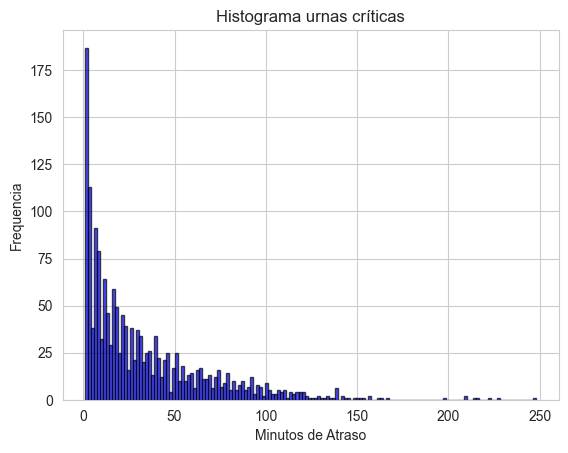

In [ ]:
urnas_1t = df_csv.query("TURNO == '1º Turno' and CONTINGENCIA == 'Não'")
df_atraso_1t = urnas_1t.query('ATRASO_FILA_MINUTOS > 0')
# df_atraso_2t = df_csv.query("TURNO == '2º Turno' and CONTINGENCIA == 'Não'")

media_atraso_1t = df_atraso_1t['ATRASO_FILA_MINUTOS'].mean()
# media_atraso_2t = df_atraso_2t['ATRASO_FILA_MINUTOS'].mean()

print(f"1º Turno: {len(df_atraso_1t)} seções atrasaram. Média de atraso: {media_atraso_1t:.1f} minutos.")
# print(f"2º Turno: {len(df_atraso_2t)} seções atrasaram. Média de atraso: {media_atraso_2t:.1f} minutos.")

plt.hist(df_atraso_1t['ATRASO_FILA_MINUTOS'], bins=150, color='blue', edgecolor='black', alpha=0.7)
plt.title('Histograma urnas críticas')
plt.xlabel('Minutos de Atraso')
plt.ylabel('Frequencia')
plt.show() 

In [ ]:
from scipy.stats import poisson

def poisson_mixture_em(data, k=3, max_iter=1000, tol=1e-6, fixed_pi=False):
    """
    Algoritmo EM para separar dados em 'k' grupos usando uma Mistura de Poisson.
    
    Parâmetros:
    - data: array de dados (ex: minutos de atraso).
    - k: número de componentes/grupos (padrão=3).
    - max_iter: número máximo de iterações.
    - tol: tolerância para convergência.
    - fixed_pi: se True, força a probabilidade de cada grupo a ser 1/k (ex: 1/3).
    """
    # Converter para numpy array caso seja uma série do pandas
    data = np.asarray(data)
    n = len(data)
    
    # 1. Inicialização
    # Escolhemos valores iniciais para os lambdas baseados nos percentis dos dados
    percentis = np.linspace(10, 90, k)
    lambdas = np.percentile(data, percentis)
    
    # Probabilidades iniciais de cada grupo (ex: 1/3, 1/3, 1/3)
    pis = np.ones(k) / k
    
    responsibilities = np.zeros((n, k))
    log_likelihoods = []
    
    for iteration in range(max_iter):
        # Calcular a probabilidade (responsabilidade) de cada ponto pertencer a cada grupo
        for j in range(k):
            responsibilities[:, j] = pis[j] * poisson.pmf(data, lambdas[j])
        
        # Soma das probabilidades para cada ponto
        resp_sum = responsibilities.sum(axis=1)
        
        # Calcular a log-verossimilhança total para checar a convergência
        log_likelihood = np.sum(np.log(resp_sum + 1e-10))
        log_likelihoods.append(log_likelihood)
        
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
            
        # Normalizar as responsabilidades para que a soma por linha seja 1
        responsibilities = responsibilities / resp_sum[:, np.newaxis]
        
        # Calcular o número esperado de pontos em cada grupo
        Nk = responsibilities.sum(axis=0)
        
        # Atualizar as taxas médias (lambdas) de cada grupo Poisson
        lambdas = np.sum(responsibilities * data[:, np.newaxis], axis=0) / Nk
        
        # Atualizar as probabilidades da mistura (pis), a menos que estejam fixas em 1/3
        if not fixed_pi:
            pis = Nk / n
            
    # Classificar cada ponto no grupo com a maior probabilidade (responsabilidade)
    labels = np.argmax(responsibilities, axis=1)
    
    # Ordenar os grupos para que Grupo 0 tenha o menor atraso, e Grupo 2 o maior
    sort_idx = np.argsort(lambdas)
    lambdas_ordenados = lambdas[sort_idx]
    pis_ordenados = pis[sort_idx]
    
    # Reatribuir as labels de acordo com a ordem correta
    label_map = {old_label: new_label for new_label, old_label in enumerate(sort_idx)}
    labels_ordenadas = np.array([label_map[l] for l in labels])
    
    return lambdas_ordenados, pis_ordenados, labels_ordenadas

dados_atraso = df_atraso_1t.loc[df_atraso_1t['ATRASO_FILA_MINUTOS'] > 0, 'ATRASO_FILA_MINUTOS'].values

lambdas_otimos, pesos_otimos, classes = poisson_mixture_em(dados_atraso, k=3, fixed_pi=True)

print("=== RESULTADOS DO ALGORITMO EM ===")
for i in range(3):
    print(f"Grupo {i+1}: Lambda (Média) = {lambdas_otimos[i]:.2f} min | Probabilidade = {pesos_otimos[i]:.2%}")

=== RESULTADOS DO ALGORITMO EM ===
Grupo 1: Lambda (Média) = 6.48 min | Probabilidade = 33.33%
Grupo 2: Lambda (Média) = 32.15 min | Probabilidade = 33.33%
Grupo 3: Lambda (Média) = 89.36 min | Probabilidade = 33.33%


In [ ]:
g1 = 6.48
g2 = 32.15
g3 = 89.36
g4 = 150

condicoes_1t = [
    (urnas_1t['ATRASO_FILA_MINUTOS'] >= g1) & (urnas_1t['ATRASO_FILA_MINUTOS'] < g2),
    (urnas_1t['ATRASO_FILA_MINUTOS'] >= g2) & (urnas_1t['ATRASO_FILA_MINUTOS'] < g3), 
    (urnas_1t['ATRASO_FILA_MINUTOS'] >= g3) & (urnas_1t['ATRASO_FILA_MINUTOS'] < g4),
    (urnas_1t['ATRASO_FILA_MINUTOS'] > g4)
]
rotulos_1t = ['1', '2', '3', '4']

urnas_1t['STATUS'] = np.select(condicoes_1t, rotulos_1t, default='0')

print(urnas_1t['STATUS'].value_counts())
urnas_1t.to_csv('../data/datasets/2022/urnas_2022.csv', index=False, sep=';', encoding='utf-8-sig')

STATUS
0    3754
1     656
2     490
3     117
4      15
Name: count, dtype: int64


In [ ]:
print("TODAS AS URNAS CRÍTICAS - 1º TURNO ")

display(
    urnas_1t[urnas_1t['STATUS'] == '4']
    .sort_values(by='ATRASO_FILA_MINUTOS', ascending=False)
)

TODAS AS URNAS CRÍTICAS - 1º TURNO 


,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,...,ULTIMO_VOTO,TIMEOUT_BIOMETRIA,TECLA_INDEVIDA,INATIVIDADE,SEM_BIOMETRIA,TITULO_INVALIDO,TTPISEC,TPBSEC,ATRASO_FILA_MINUTOS,STATUS
8925,32158,Riachão Do Dantas,0004,0134,1º Turno,Não,217,81.93,62.29,134,...,21:08:54,97,551,37,11,9,1665,8328,248,4
10245,32433,Siriri,0005,0139,1º Turno,Não,171,90.12,65.76,110,...,20:47:40,30,841,14,30,26,630,7054,227,4
8941,32158,Riachão Do Dantas,0004,0151,1º Turno,Não,225,83.12,59.25,106,...,20:42:28,16,1096,21,21,35,945,5268,222,4
3313,31216,Canhoba,0008,0075,1º Turno,Não,244,83.16,157.11,145,...,20:36:16,0,684,42,12,6,1890,5066,216,4
8916,32158,Riachão Do Dantas,0004,0111,1º Turno,Não,195,97.04,71.88,102,...,20:35:22,107,902,23,14,11,1035,6845,215,4
6539,31739,Macambira,0024,0067,1º Turno,Não,214,68.82,43.77,114,...,20:30:19,29,553,9,15,3,405,10625,210,4
4415,31437,Feira Nova,0016,0148,1º Turno,Não,179,93.60,80.35,104,...,20:29:02,142,505,22,15,9,990,9983,209,4
8929,32158,Riachão Do Dantas,0004,0138,1º Turno,Não,248,71.62,38.26,106,...,20:18:51,37,589,13,31,28,585,6963,198,4
4220,31410,Estância,0006,0112,1º Turno,Não,226,88.34,64.53,100,...,19:46:41,14,811,14,21,7,630,5061,166,4
3177,31151,Boquim,0004,0127,1º Turno,Não,212,89.40,62.02,95,...,19:44:03,3,800,13,17,6,585,4377,164,4


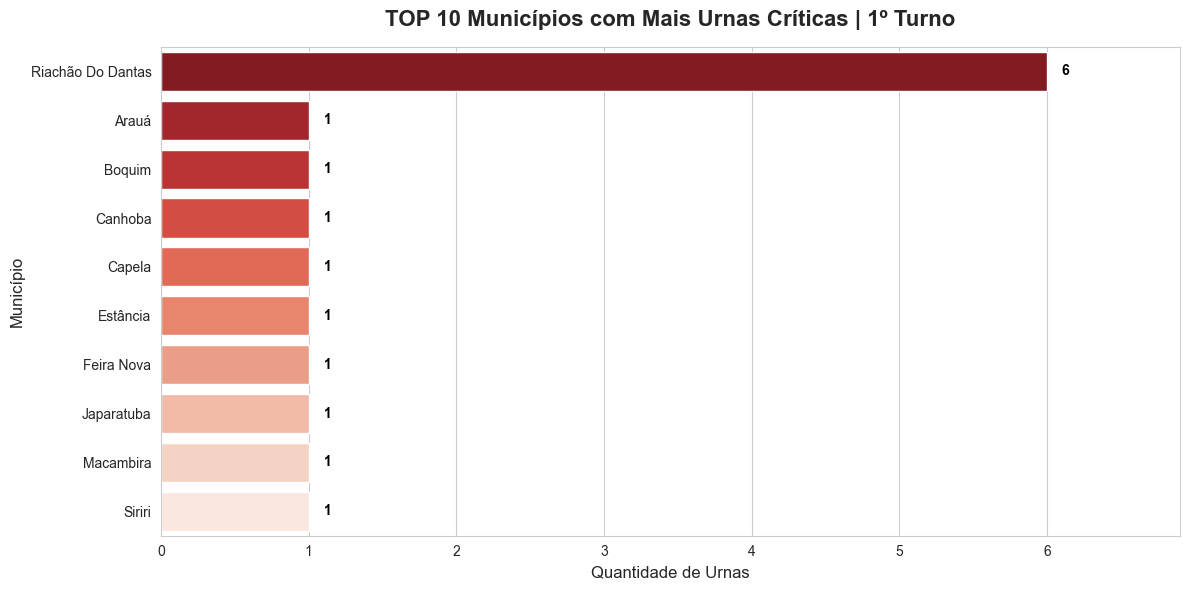

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparando os dados: Pegar apenas as urnas críticas do 1º turno
criticas_1t = urnas_1t[urnas_1t['STATUS'] == '4']

# 2. Contando quantas urnas críticas cada município teve e pegando o Top 10
top10_cidades = criticas_1t['NM_MUNICIPIO'].value_counts().head(10).reset_index()
top10_cidades.columns = ['Município', 'Qtd_Urnas_Criticas']

# 3. Configurando a beleza do gráfico
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Fundo limpo

# 4. Desenhando o gráfico de barras horizontais
grafico = sns.barplot(
    x='Qtd_Urnas_Criticas', 
    y='Município',
    hue='Município',
    data=top10_cidades, 
    palette='Reds_r', # Paleta de cores vermelhas (reforçando a ideia de alerta)
    legend=False
)

# 5. Adicionando os números na ponta de cada barra
for index, value in enumerate(top10_cidades['Qtd_Urnas_Criticas']):
    grafico.text(value + 0.1, index, str(value), color='black', va='center', fontweight='bold')

# 6. Títulos e eixos
plt.title('TOP 10 Municípios com Mais Urnas Críticas | 1º Turno', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Quantidade de Urnas', fontsize=12)
plt.ylabel('Município', fontsize=12)
plt.xlim(0, top10_cidades['Qtd_Urnas_Criticas'].max() * 1.15) # Dá um espaço extra para o texto caber

# Exibindo o gráfico final
plt.tight_layout()
plt.show()
# criticas_1t.to_csv('secoes_criticas_2022.csv', index=False, sep=';', encoding='utf-8-sig')

STATUS
0     9.003996
1    12.370427
2    17.702041
3    24.068376
4    48.933333
Name: TIMEOUT_BIOMETRIA, dtype: float64


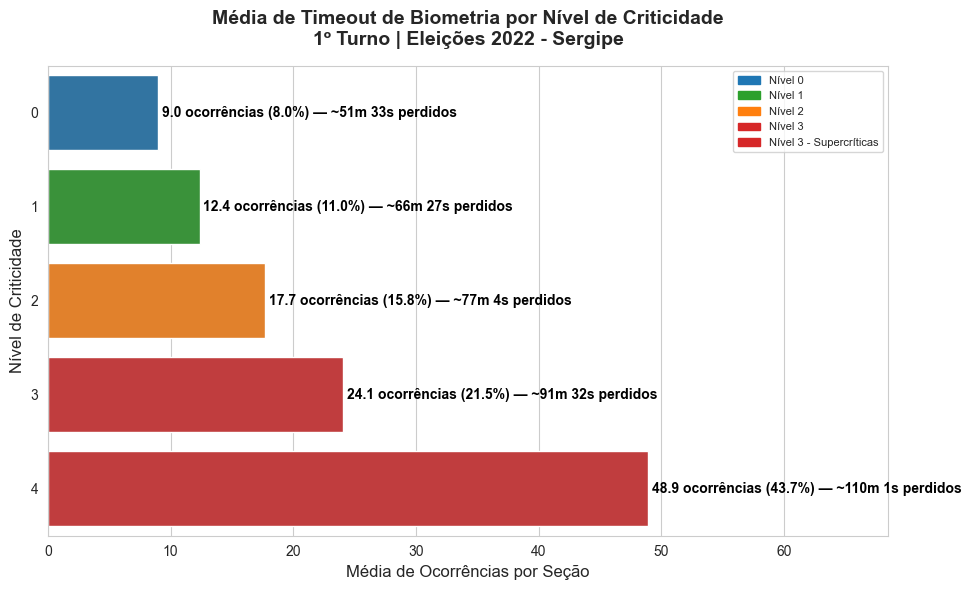

In [ ]:
media_timeout_biometria = urnas_1t.groupby('STATUS')['TIMEOUT_BIOMETRIA'].mean()
print(media_timeout_biometria)
media_tempo_bio = urnas_1t.groupby('STATUS')['TPBSEC'].mean()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:red']
grafico = sns.barplot(x=media_timeout_biometria.values, 
                      y=media_timeout_biometria.index.astype(str),
                      hue=media_timeout_biometria.index.astype(str),
                      palette=cores,
                      legend=False
                     )

for index, value in enumerate(media_timeout_biometria.values):
    pct = (value / media_timeout_biometria.sum() * 100).round(1)
    tempo = media_tempo_bio.values[index]
    minutos = int(tempo) // 60
    segundos = int(tempo) % 60
    grafico.text(value + 0.3, index, 
                 f'{value:.1f} ocorrências ({pct}%) — ~{minutos}m {segundos}s perdidos', 
                 color='black', va='center', fontweight='bold', fontsize=10)
    
plt.title('Média de Timeout de Biometria por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_timeout_biometria.max() * 1.4)

labels = ['Nível 0', 'Nível 1', 'Nível 2', 'Nível 3', 'Nível 3 - Supercríticas']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

STATUS
0    406.543687
1    560.396341
2    630.565306
3    716.470085
4    708.400000
Name: TECLA_INDEVIDA, dtype: float64


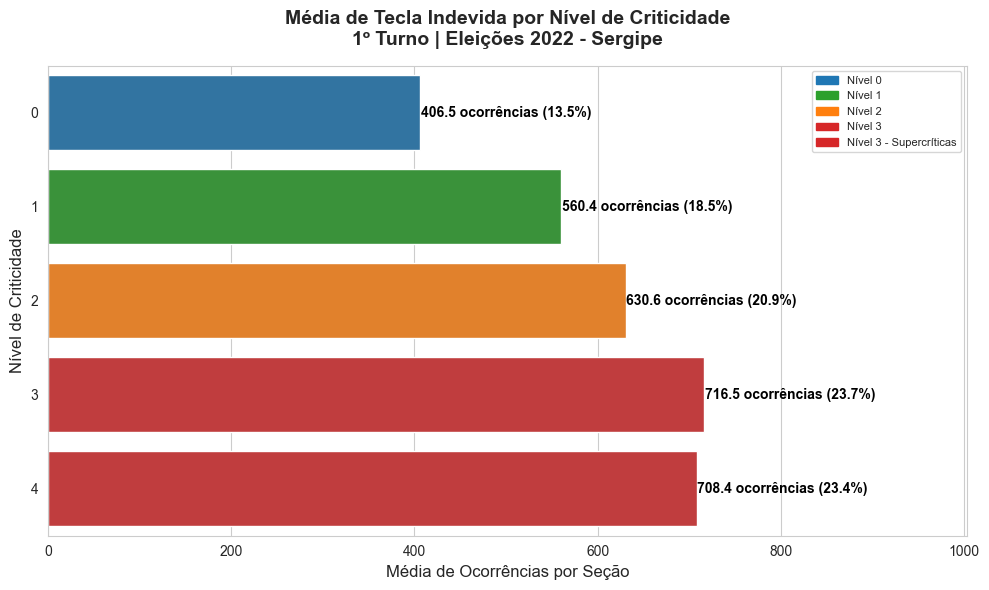

In [ ]:
media_tecla_indevida = urnas_1t.groupby('STATUS')['TECLA_INDEVIDA'].mean()
print(media_tecla_indevida)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:red']
grafico = sns.barplot(x=media_tecla_indevida.values, 
                      y=media_tecla_indevida.index.astype(str),
                      hue=media_tecla_indevida.index.astype(str),
                      palette=cores,
                      legend=False
                     )

for index, value in enumerate(media_tecla_indevida.values):
    pct = (value / media_tecla_indevida.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Tecla Indevida por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_tecla_indevida.max() * 1.4)

labels = ['Nível 0', 'Nível 1', 'Nível 2', 'Nível 3', 'Nível 3 - Supercríticas']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

STATUS
0     8.428343
1    10.562500
2    12.459184
3    15.094017
4    21.266667
Name: INATIVIDADE, dtype: float64


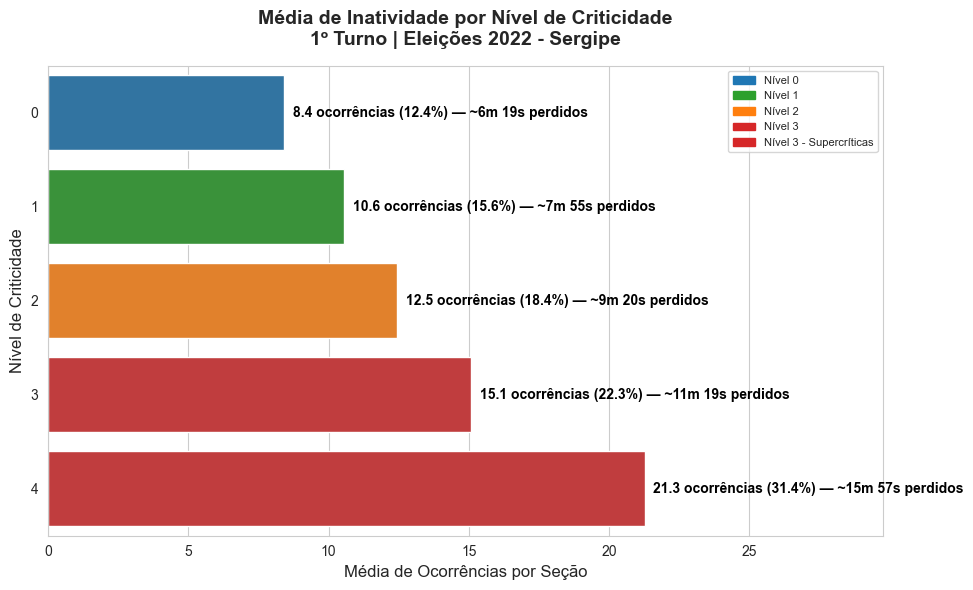

In [ ]:
media_inatividade = urnas_1t.groupby('STATUS')['INATIVIDADE'].mean()
print(media_inatividade)
media_tempo_inat = urnas_1t.groupby('STATUS')['TTPISEC'].mean()

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:red']
grafico = sns.barplot(x=media_inatividade.values, 
                      y=media_inatividade.index.astype(str),
                      hue=media_inatividade.index.astype(str),
                      palette=cores,
                      legend=False)

for index, value in enumerate(media_inatividade.values):
    pct = (value / media_inatividade.sum() * 100).round(1)
    tempo = media_tempo_inat.values[index]
    minutos = int(tempo) // 60
    segundos = int(tempo) % 60
    grafico.text(value + 0.3, index, 
                 f'{value:.1f} ocorrências ({pct}%) — ~{minutos}m {segundos}s perdidos', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Inatividade por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_inatividade.max() * 1.4)

labels = ['Nível 0', 'Nível 1', 'Nível 2', 'Nível 3', 'Nível 3 - Supercríticas']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

STATUS
0    15.742142
1    14.548780
2    13.967347
3    14.572650
4    17.200000
Name: SEM_BIOMETRIA, dtype: float64


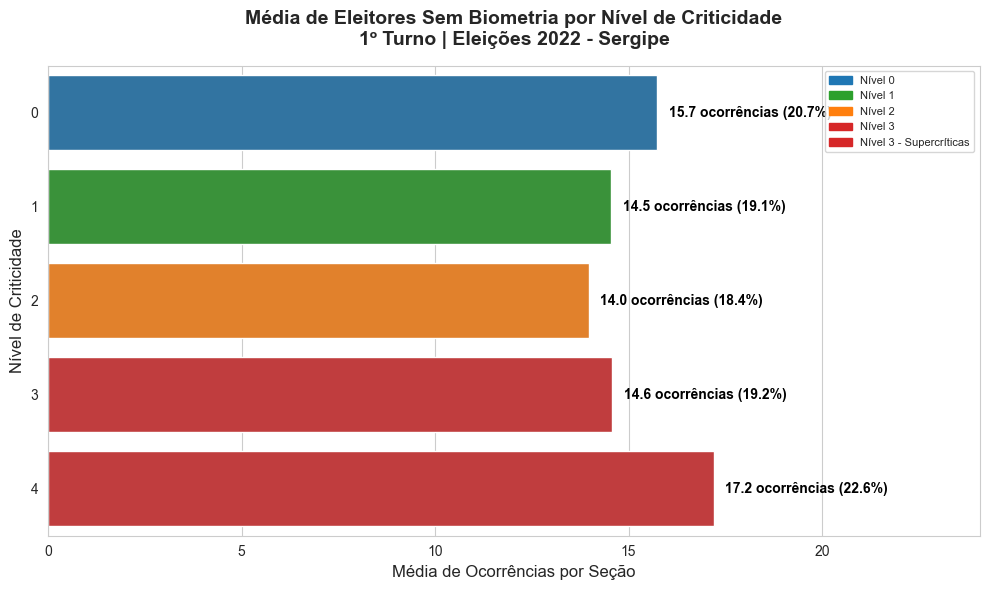

In [ ]:
media_sem_biometria = urnas_1t.groupby('STATUS')['SEM_BIOMETRIA'].mean()
print(media_sem_biometria)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:red']
grafico = sns.barplot(x=media_sem_biometria.values, 
                      y=media_sem_biometria.index.astype(str),
                      hue=media_sem_biometria.index.astype(str),
                      palette=cores,
                      legend=False
                     )

for index, value in enumerate(media_sem_biometria.values):
    pct = (value / media_sem_biometria.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Eleitores Sem Biometria por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_sem_biometria.max() * 1.4)

labels = ['Nível 0', 'Nível 1', 'Nível 2', 'Nível 3', 'Nível 3 - Supercríticas']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

STATUS
0    10.535162
1    12.524390
2    13.495918
3    13.752137
4    12.933333
Name: TITULO_INVALIDO, dtype: float64


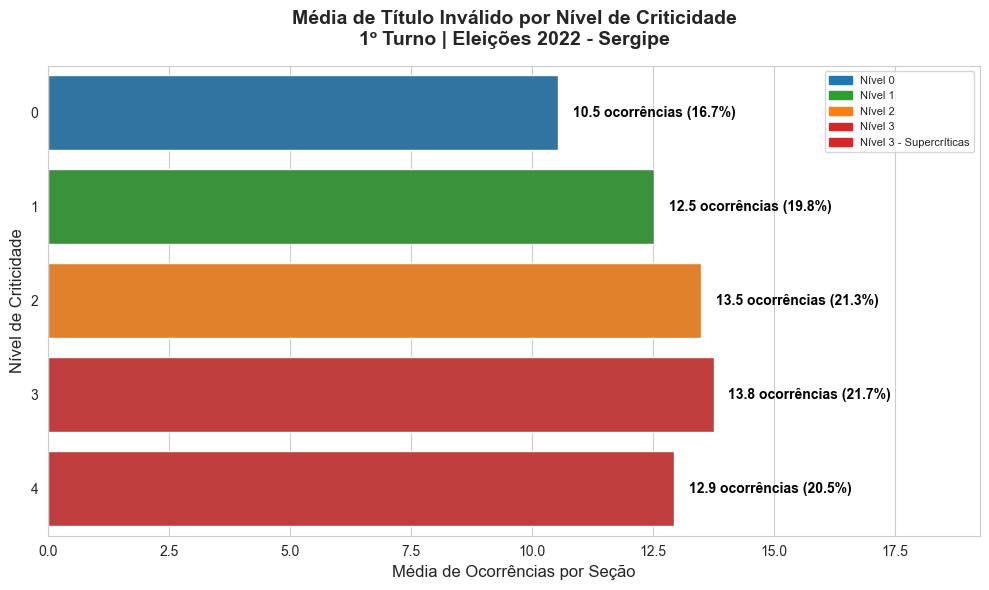

In [ ]:
media_titulo_invalido = urnas_1t.groupby('STATUS')['TITULO_INVALIDO'].mean()
print(media_titulo_invalido)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

cores = ['tab:blue', 'tab:green', 'tab:orange', 'tab:red', 'tab:red']
grafico = sns.barplot(x=media_titulo_invalido.values, 
                      y=media_titulo_invalido.index.astype(str),
                      hue=media_titulo_invalido.index.astype(str),
                      palette=cores,
                      legend=False
                     )

for index, value in enumerate(media_titulo_invalido.values):
    pct = (value / media_titulo_invalido.sum() * 100).round(1)
    grafico.text(value + 0.3, index, f'{value:.1f} ocorrências ({pct}%)', 
                 color='black', va='center', fontweight='bold', fontsize=10)

plt.title('Média de Título Inválido por Nível de Criticidade\n1º Turno | Eleições 2022 - Sergipe', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Média de Ocorrências por Seção', fontsize=12)
plt.ylabel('Nível de Criticidade', fontsize=12)
plt.xlim(0, media_titulo_invalido.max() * 1.4)

labels = ['Nível 0', 'Nível 1', 'Nível 2', 'Nível 3', 'Nível 3 - Supercríticas']
handles = [plt.Rectangle((0,0),1,1, color=c) for c in cores]
plt.legend(handles, labels, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# nivel3_2018 = pd.read_csv('../data/datasets/secoes_criticas_2018.csv', sep=';', encoding='utf-8-sig')
# criticas_2022 = pd.read_csv('../data/datasets/df_atraso_2022.csv', sep=';', encoding='utf-8-sig')

df_perfil = pd.read_csv('../data/datasets/2022/perfil_eleitor_secao_2022_SE.csv', sep=';', encoding='latin1')

df_perfil['NM_MUNICIPIO'] = df_perfil['NM_MUNICIPIO'].str.upper()
df_perfil['CD_MUNICIPIO'] = df_perfil['CD_MUNICIPIO'].astype(str)
df_perfil['NR_ZONA'] = df_perfil['NR_ZONA'].astype(int)
df_perfil['NR_SECAO'] = df_perfil['NR_SECAO'].astype(int)

urnas_1t['NM_MUNICIPIO'] = urnas_1t['NM_MUNICIPIO'].str.upper()
urnas_1t['CD_MUNICIPIO'] = urnas_1t['CD_MUNICIPIO'].astype(str)
urnas_1t['NR_ZONA'] = urnas_1t['NR_ZONA'].astype(int)
urnas_1t['NR_SECAO'] = urnas_1t['NR_SECAO'].astype(int)

In [ ]:
criticas_2022 = urnas_1t.merge(
    df_perfil,
    on=['CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO'],
    how='inner'
)

df_n3 = criticas_2022.query("STATUS == '4' or STATUS == '3'")
df_n2 = criticas_2022.query("STATUS == '2'")
df_n1 = criticas_2022.query("STATUS == '1'")

display(df_n3)

,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,...,DS_IDENTIDADE_GENERO,CD_QUILOMBOLA,DS_QUILOMBOLA,CD_INTERPRETE_LIBRAS,DS_INTERPRETE_LIBRAS,TP_OBRIGATORIEDADE_VOTO,QT_ELEITORES_PERFIL,QT_ELEITORES_BIOMETRIA,QT_ELEITORES_DEFICIENCIA,QT_ELEITORES_INC_NM_SOCIAL
9230,31038,AQUIDABÃ,3,114,1º Turno,Não,217,82.97,62.54,51,...,#NE,-3,#NE,-3,#NE,Obrigatório,4,4,0,0
9231,31038,AQUIDABÃ,3,114,1º Turno,Não,217,82.97,62.54,51,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0
9232,31038,AQUIDABÃ,3,114,1º Turno,Não,217,82.97,62.54,51,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
9233,31038,AQUIDABÃ,3,114,1º Turno,Não,217,82.97,62.54,51,...,#NE,-3,#NE,-3,#NE,Facultativo,2,2,0,0
9234,31038,AQUIDABÃ,3,114,1º Turno,Não,217,82.97,62.54,51,...,#NE,-3,#NE,-3,#NE,Obrigatório,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689671,32514,UMBAÚBA,35,101,1º Turno,Não,239,78.39,48.16,52,...,#NE,-3,#NE,-3,#NE,Facultativo,3,3,0,0
689672,32514,UMBAÚBA,35,101,1º Turno,Não,239,78.39,48.16,52,...,#NE,-3,#NE,-3,#NE,Obrigatório,2,2,0,0
689673,32514,UMBAÚBA,35,101,1º Turno,Não,239,78.39,48.16,52,...,#NE,-3,#NE,-3,#NE,Obrigatório,3,3,0,0
689674,32514,UMBAÚBA,35,101,1º Turno,Não,239,78.39,48.16,52,...,#NE,-3,#NE,-3,#NE,Facultativo,2,2,0,0


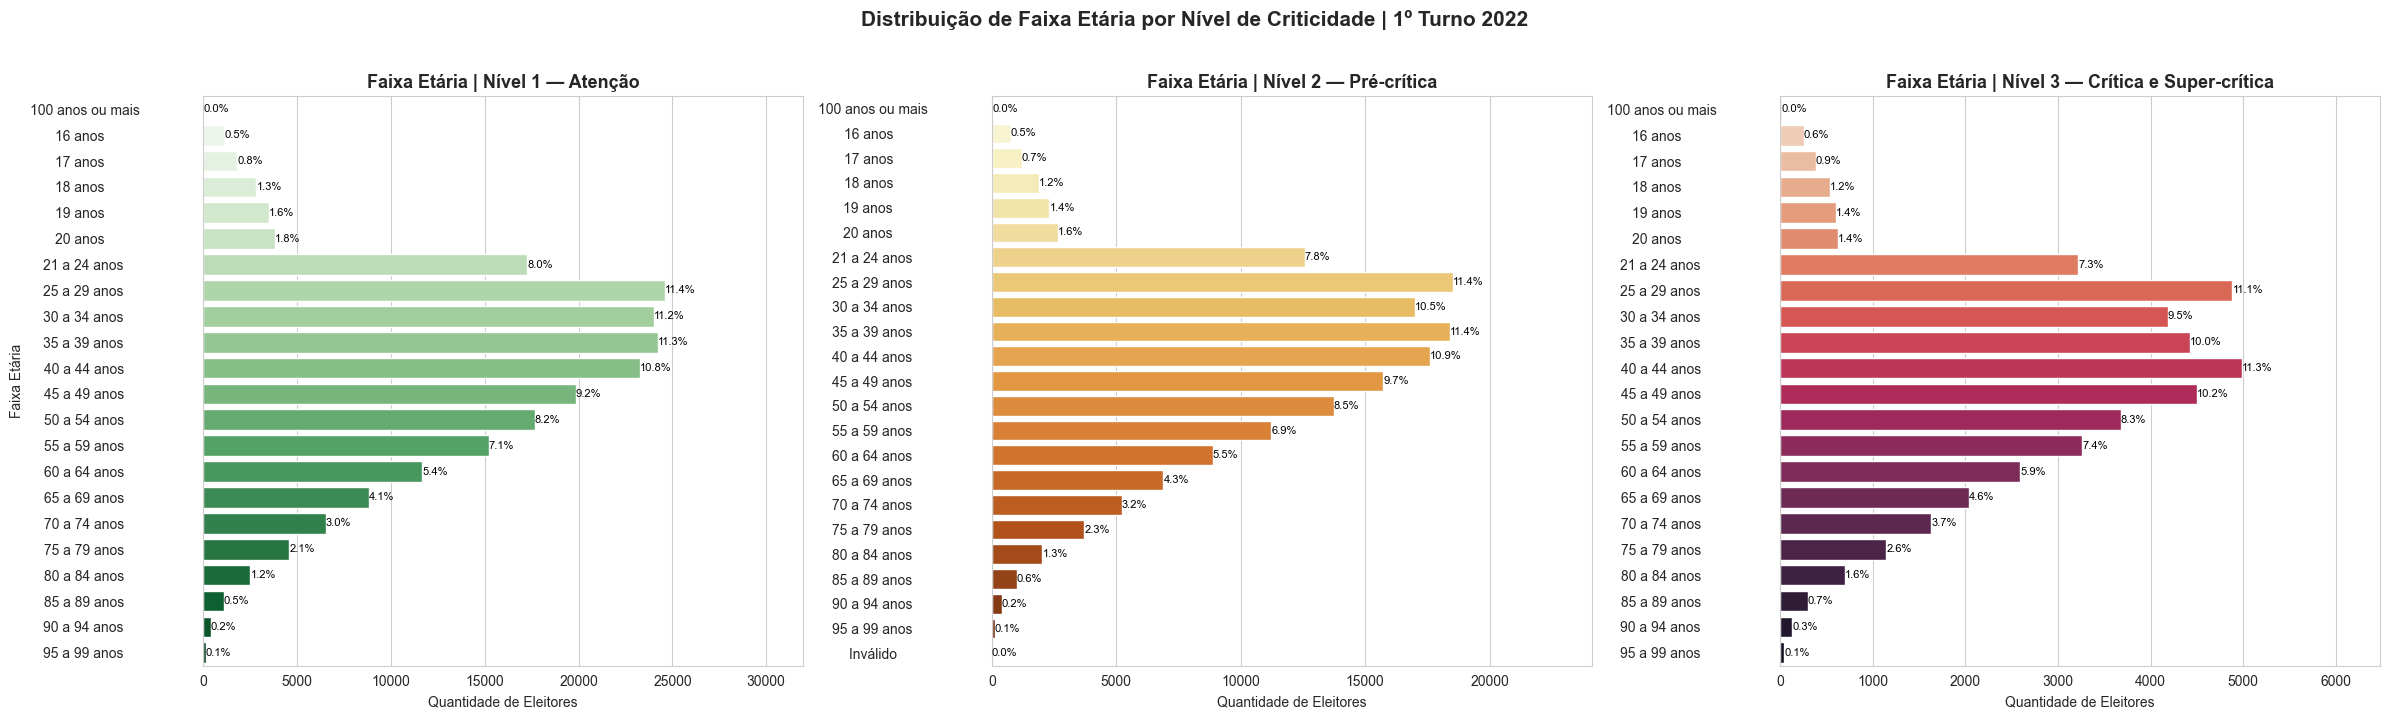

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7))

# Nível 1
df_idade_n1 = df_n1.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
# print(df_idade_n1)
sns.barplot(x=df_idade_n1.values, y=df_idade_n1.index, hue=df_idade_n1.index, palette='Greens', legend=False, ax=ax1)
total_n1 = df_idade_n1.sum()
for index, value in enumerate(df_idade_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax1.set_title('Faixa Etária | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Faixa Etária')
ax1.set_xlim(0, df_idade_n1.max() * 1.3)

# Nível 2
df_idade_n2 = df_n2.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
# print(df_idade_n2)
sns.barplot(x=df_idade_n2.values, y=df_idade_n2.index, hue=df_idade_n2.index, palette='YlOrBr', legend=False, ax=ax2)
total_n2 = df_idade_n2.sum()
for index, value in enumerate(df_idade_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax2.set_title('Faixa Etária | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_idade_n2.max() * 1.3)

# Nível 3 (Crítico e Super-crítico)
df_idade_n3 = df_n3.groupby('DS_FAIXA_ETARIA')['QT_ELEITORES_PERFIL'].sum()
# print(df_idade_n3)
sns.barplot(x=df_idade_n3.values, y=df_idade_n3.index, hue=df_idade_n3.index, palette='rocket_r', legend=False, ax=ax3)
total_n3 = df_idade_n3.sum()
for index, value in enumerate(df_idade_n3.values):
    pct = (value / total_n3 * 100).round(1)
    ax3.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=8)
ax3.set_title('Faixa Etária | Nível 3 — Crítica e Super-crítica', fontsize=13, fontweight='bold')
ax3.set_xlabel('Quantidade de Eleitores')
ax3.set_ylabel('')
ax3.set_xlim(0, df_idade_n3.max() * 1.3)

plt.suptitle('Distribuição de Faixa Etária por Nível de Criticidade | 1º Turno 2022', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

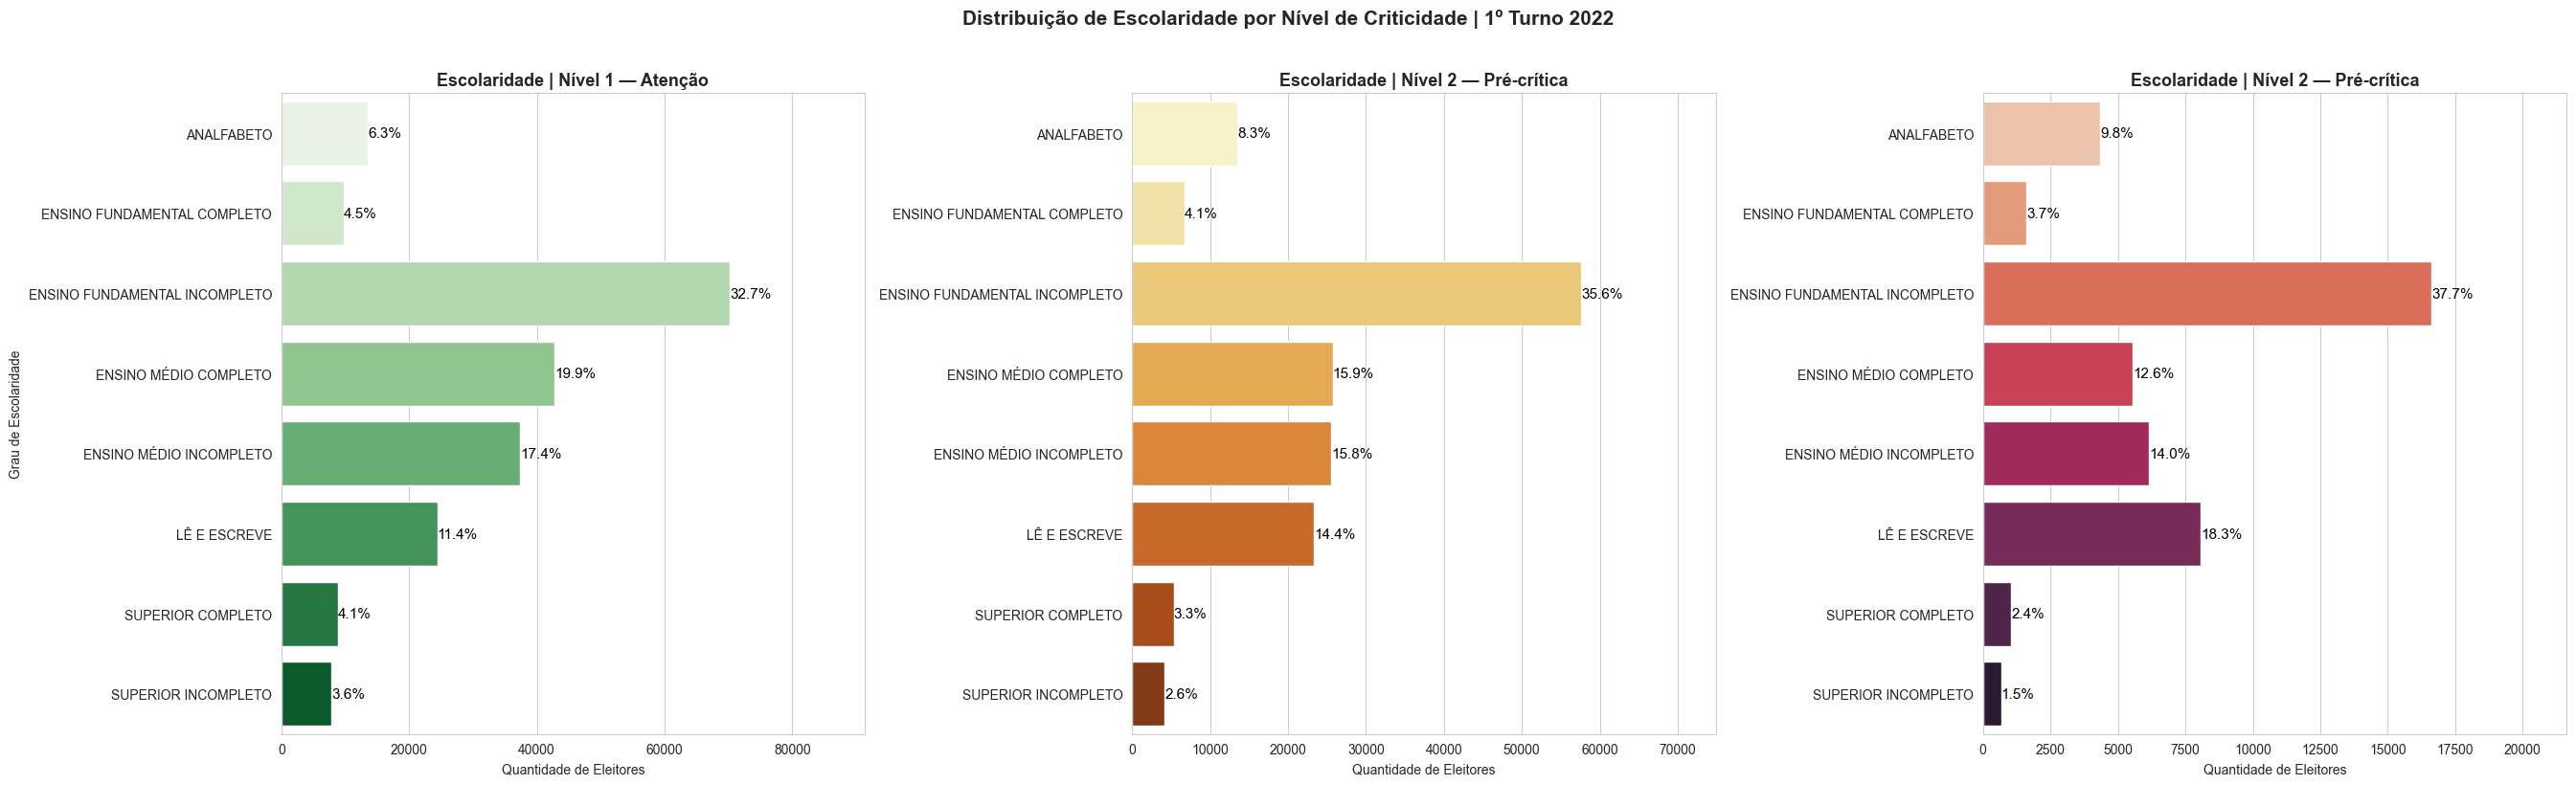

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(27, 8))

# Nível 1
df_esc_n1 = df_n1.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
# print(df_esc_n1)
sns.barplot(x=df_esc_n1.values, y=df_esc_n1.index, hue=df_esc_n1.index, palette='Greens', legend=False, ax=ax1)
total_n1 = df_esc_n1.sum()
for index, value in enumerate(df_esc_n1.values):
    pct = (value / total_n1 * 100).round(1)
    ax1.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=11)
ax1.set_title('Escolaridade | Nível 1 — Atenção', fontsize=13, fontweight='bold')
ax1.set_xlabel('Quantidade de Eleitores')
ax1.set_ylabel('Grau de Escolaridade')
ax1.set_xlim(0, df_esc_n1.max() * 1.3)

# Nível 2
df_esc_n2 = df_n2.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
# print(df_esc_n2)
sns.barplot(x=df_esc_n2.values, y=df_esc_n2.index, hue=df_esc_n2.index, palette='YlOrBr', legend=False, ax=ax2)
total_n2 = df_esc_n2.sum()
for index, value in enumerate(df_esc_n2.values):
    pct = (value / total_n2 * 100).round(1)
    ax2.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=11)
ax2.set_title('Escolaridade | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax2.set_xlabel('Quantidade de Eleitores')
ax2.set_ylabel('')
ax2.set_xlim(0, df_esc_n2.max() * 1.3)

# Nível 3 (Críticos e Super-críticos)
df_esc_n3 = df_n3.groupby('DS_GRAU_ESCOLARIDADE')['QT_ELEITORES_PERFIL'].sum()
# print(df_esc_n3)
sns.barplot(x=df_esc_n3.values, y=df_esc_n3.index, hue=df_esc_n3.index, palette='rocket_r', legend=False, ax=ax3)
total_n3 = df_esc_n3.sum()
for index, value in enumerate(df_esc_n3.values):
    pct = (value / total_n3 * 100).round(1)
    ax3.text(value + 0.5, index, f'{pct}%', color='black', va='center', fontsize=11)
ax3.set_title('Escolaridade | Nível 2 — Pré-crítica', fontsize=13, fontweight='bold')
ax3.set_xlabel('Quantidade de Eleitores')
ax3.set_ylabel('')
ax3.set_xlim(0, df_esc_n3.max() * 1.3)

plt.suptitle('Distribuição de Escolaridade por Nível de Criticidade | 1º Turno 2022', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
total_eleitores = df_n3['QT_ELEITORES_PERFIL'].sum()
pct_pcd = (10 / total_eleitores * 100).round(2)
print(f"Total de eleitores nas seções críticas: {total_eleitores}")
print(f"PCD representa: {pct_pcd}%")
total_biometria = df_n3['QT_ELEITORES_BIOMETRIA'].sum()
total_eleitores = df_n3['QT_ELEITORES_PERFIL'].sum()
pct_biometria = (total_biometria / total_eleitores * 100).round(2)
print(f"Total de eleitores com biometria: {total_biometria}")
print(f"Biometria representa: {pct_biometria}%")

Total de eleitores nas seções críticas: 44103
PCD representa: 0.02%
Total de eleitores com biometria: 42325
Biometria representa: 95.97%


In [ ]:
# PCD

lista = [df_n1, df_n2, df_n3]

for i in range(len(lista)):
    total_eleitores = lista[i]['QT_ELEITORES_PERFIL'].sum()
    total_pcd = lista[i]['QT_ELEITORES_DEFICIENCIA'].sum()
    total_el = lista[i]['QT_ELEITORES_PERFIL'].sum()
    total_bio = lista[i]['QT_ELEITORES_BIOMETRIA'].sum()
    print(f"---------------- Nível {i+1} -------------------")
    print(f"Total de eleitores nas seções: {total_eleitores}")
    print(f"Total PCD: {total_pcd}")
    print(f"Representa: {(total_pcd/total_el*100):.2f}%")
    print(f"Total com biometria: {total_bio}")
    print(f"Representa: {(total_bio/total_el*100):.2f}%\n")

---------------- Nível 1 -------------------
Total de eleitores nas seções: 214944
Total PCD: 1050
Representa: 0.49%
Total com biometria: 204117
Representa: 94.96%

---------------- Nível 2 -------------------
Total de eleitores nas seções: 161879
Total PCD: 650
Representa: 0.40%
Total com biometria: 155235
Representa: 95.90%

---------------- Nível 3 -------------------
Total de eleitores nas seções: 44103
Total PCD: 179
Representa: 0.41%
Total com biometria: 42325
Representa: 95.97%



In [ ]:
chaves_urna = ['CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO']

colunas_maquina = [
    'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'TURNO', 'CONTINGENCIA', 
    'QT_ELEITORES_ANTES_17', 'DELTA_T_ANTES_17', 'DESVIO_ANTES_17', 
    'QT_ELEITORES_DEPOIS_17', 'DELTA_T_DEPOIS_17', 'DESVIO_DEPOIS_17', 
    'ULTIMO_VOTO', 'TIMEOUT_BIOMETRIA', 'TECLA_INDEVIDA', 'INATIVIDADE', 
    'SEM_BIOMETRIA', 'TITULO_INVALIDO', 'ATRASO_FILA_MINUTOS', 'STATUS',
]

In [ ]:
df_urnas_unicas = criticas_2022[colunas_maquina].drop_duplicates(subset=chaves_urna)

df_escolaridade = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_GRAU_ESCOLARIDADE',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_escolaridade.columns = chaves_urna + [f'ESC_{col}' for col in df_escolaridade.columns[len(chaves_urna):]]

df_idade = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_FAIXA_ETARIA',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_idade.columns = chaves_urna + [f'IDADE_{col}' for col in df_idade.columns[len(chaves_urna):]]

df_genero = criticas_2022.pivot_table(
    index=chaves_urna,
    columns='DS_GENERO',
    values='QT_ELEITORES_PERFIL',
    aggfunc='sum',
    fill_value=0
).reset_index()

df_genero.columns = chaves_urna + [f'GENERO_{col}' for col in df_genero.columns[len(chaves_urna):]]

df_pcd = criticas_2022.groupby(chaves_urna)['QT_ELEITORES_DEFICIENCIA'].sum().reset_index()
df_pcd.rename(columns={'QT_ELEITORES_DEFICIENCIA': 'QTD_PCD'}, inplace=True)

df_bio = criticas_2022.groupby(chaves_urna)['QT_ELEITORES_BIOMETRIA'].sum().reset_index()
df_bio.rename(columns={'QT_ELEITORES_BIOMETRIA': 'QTD_PERFIL_BIOMETRIA'}, inplace=True)

df_final = df_urnas_unicas.copy()

df_final = pd.merge(df_final, df_escolaridade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_idade, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_genero, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_pcd, on=chaves_urna, how='left')
df_final = pd.merge(df_final, df_bio, on=chaves_urna, how='left')
df_tempo = criticas_2022[chaves_urna + ['TPBSEC', 'TTPISEC']].drop_duplicates(subset=chaves_urna)
df_final = pd.merge(df_final, df_tempo, on=chaves_urna, how='left')

colunas_novas = [col for col in df_final.columns if col not in colunas_maquina]
df_final[colunas_novas] = df_final[colunas_novas].fillna(0).astype(int)

print(f"Dimensões do arquivo final: {len(df_final)} urnas e {len(df_final.columns)} colunas.")
display(df_final.head())

df_final.to_csv("../data/datasets/2022/urnas_completas_2022_1t.csv", index=False, sep=";", encoding="utf-8-sig")

Dimensões do arquivo final: 5019 urnas e 57 colunas.


,CD_MUNICIPIO,NM_MUNICIPIO,NR_ZONA,NR_SECAO,TURNO,CONTINGENCIA,QT_ELEITORES_ANTES_17,DELTA_T_ANTES_17,DESVIO_ANTES_17,QT_ELEITORES_DEPOIS_17,...,IDADE_85 a 89 anos,IDADE_90 a 94 anos,IDADE_95 a 99 anos,IDADE_Inválido,GENERO_FEMININO,GENERO_MASCULINO,QTD_PCD,QTD_PERFIL_BIOMETRIA,TPBSEC,TTPISEC
0,31003,SANTANA DO SÃO FRANCISCO,15,40,1º Turno,Não,223,78.31,57.43,0,...,7,3,1,0,165,122,1,266,2023,405
1,31003,SANTANA DO SÃO FRANCISCO,15,41,1º Turno,Não,231,77.33,78.81,1,...,3,1,1,0,154,137,0,278,4294,855
2,31003,SANTANA DO SÃO FRANCISCO,15,42,1º Turno,Não,221,81.06,61.17,0,...,3,1,0,0,156,135,0,271,3894,540
3,31003,SANTANA DO SÃO FRANCISCO,15,43,1º Turno,Não,228,87.37,65.81,1,...,6,0,0,0,156,134,1,281,2785,810
4,31003,SANTANA DO SÃO FRANCISCO,15,44,1º Turno,Não,213,88.79,84.97,2,...,2,1,0,0,130,162,0,280,3949,1080


Total de urnas nível 4: 15

Gerando gráficos: ARAUÁ | Zona 4 | Seção 129


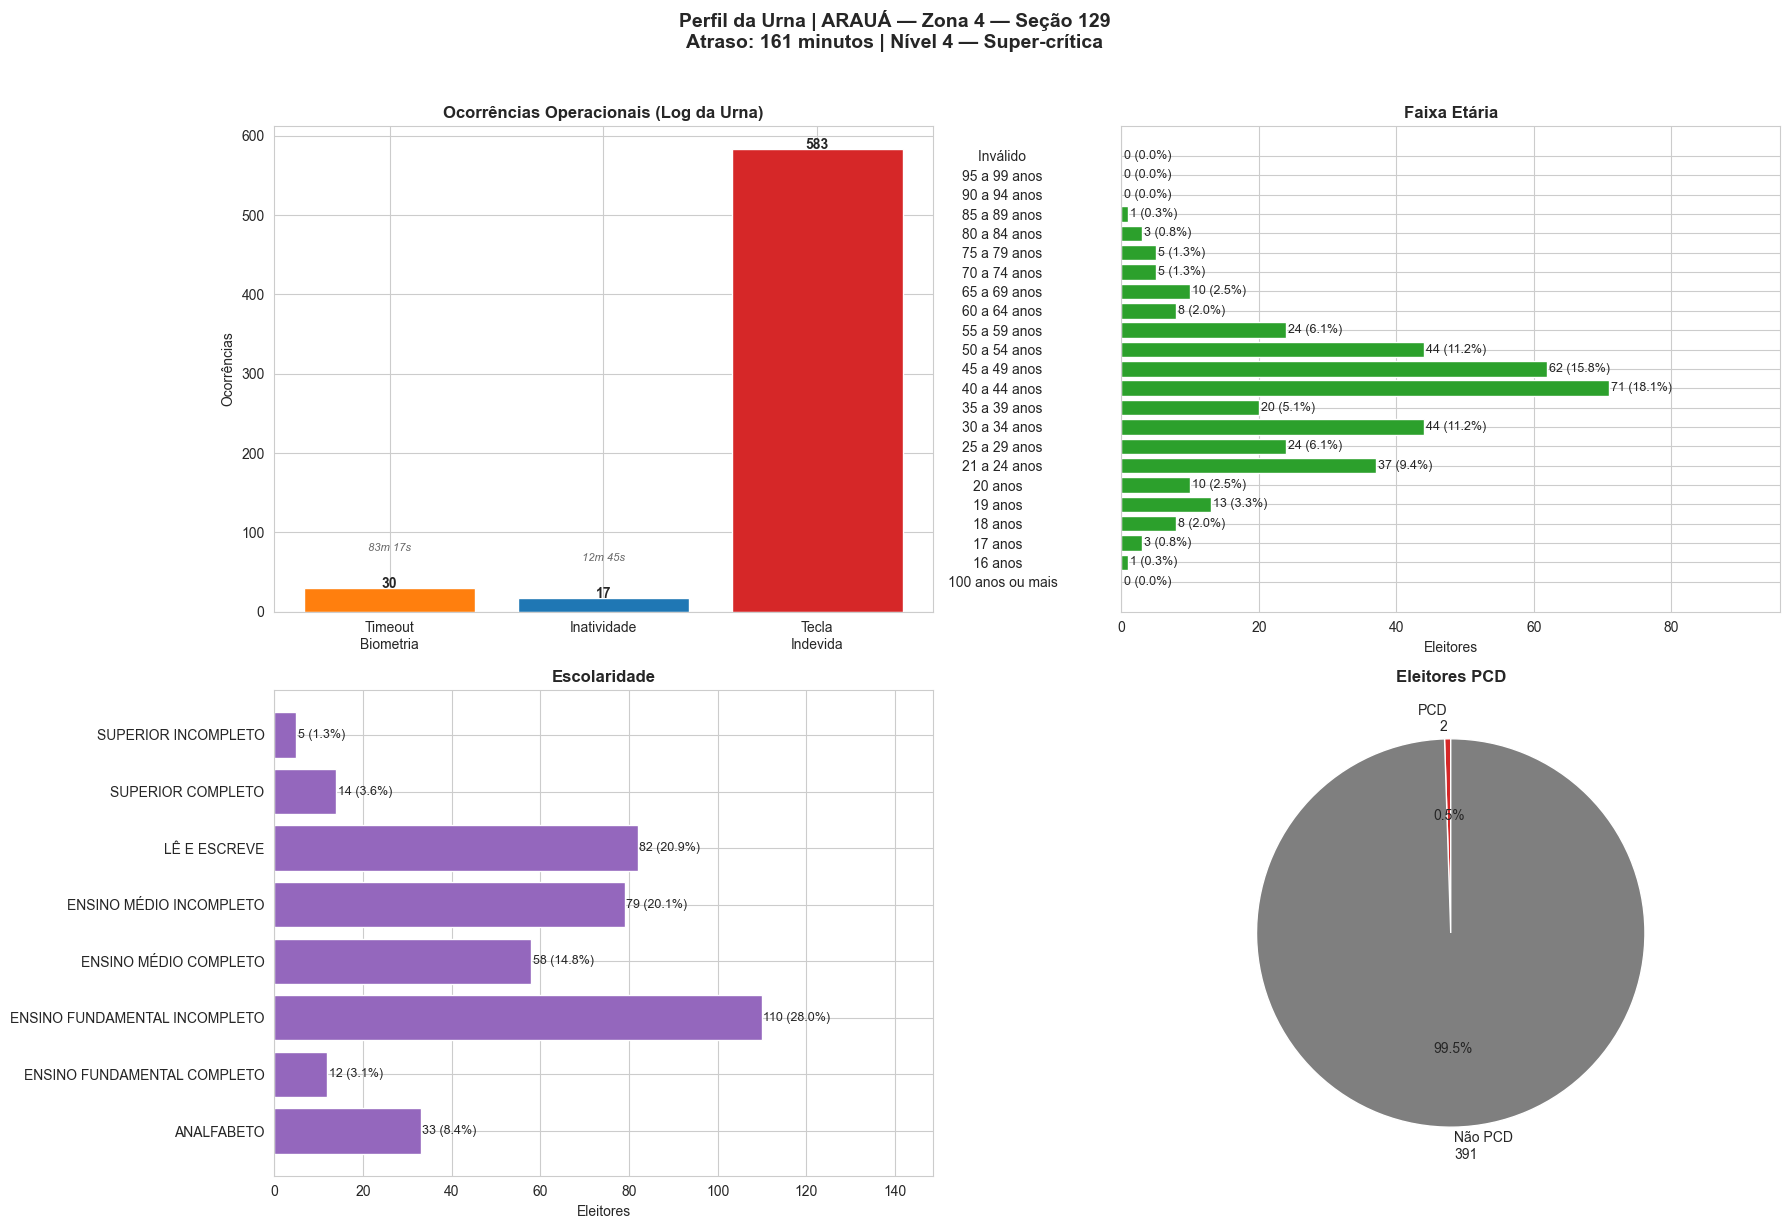


Gerando gráficos: BOQUIM | Zona 4 | Seção 127


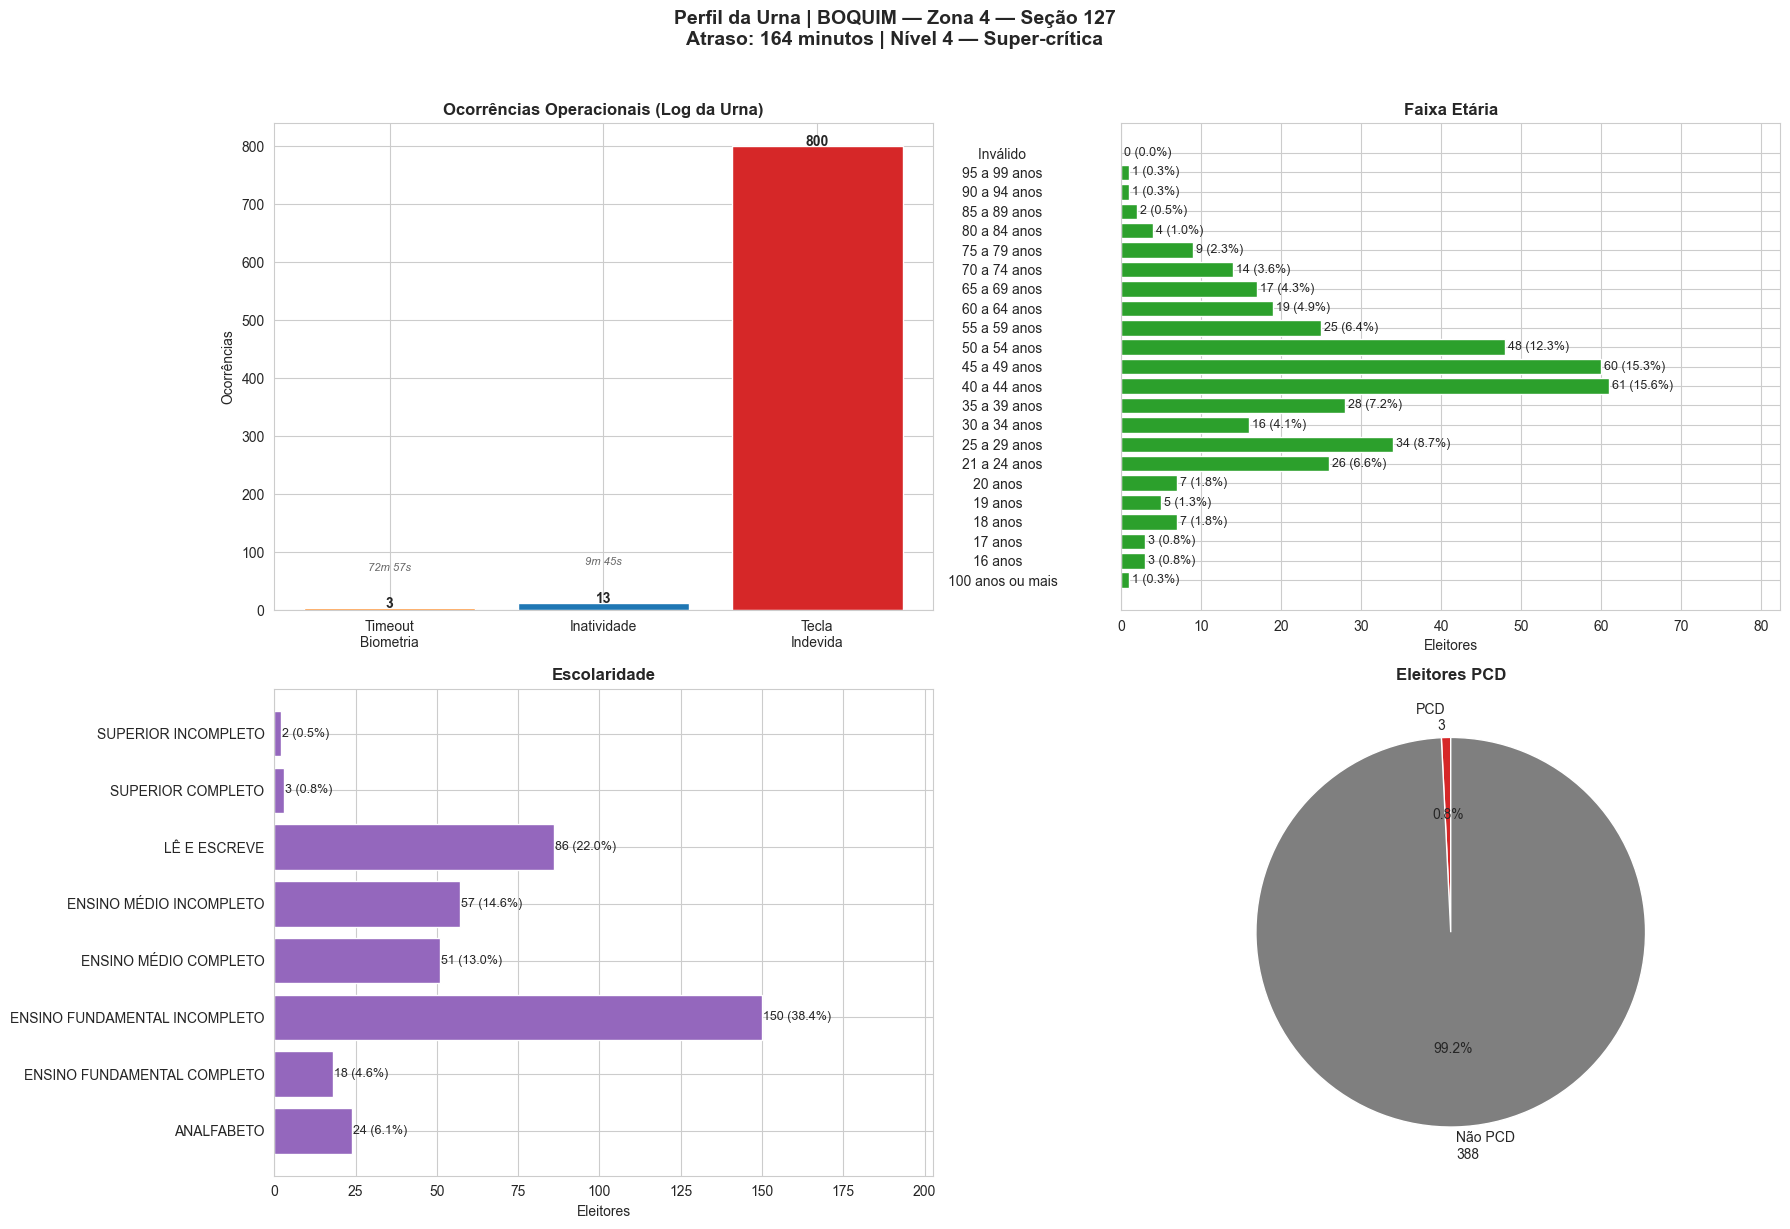


Gerando gráficos: CANHOBA | Zona 8 | Seção 75


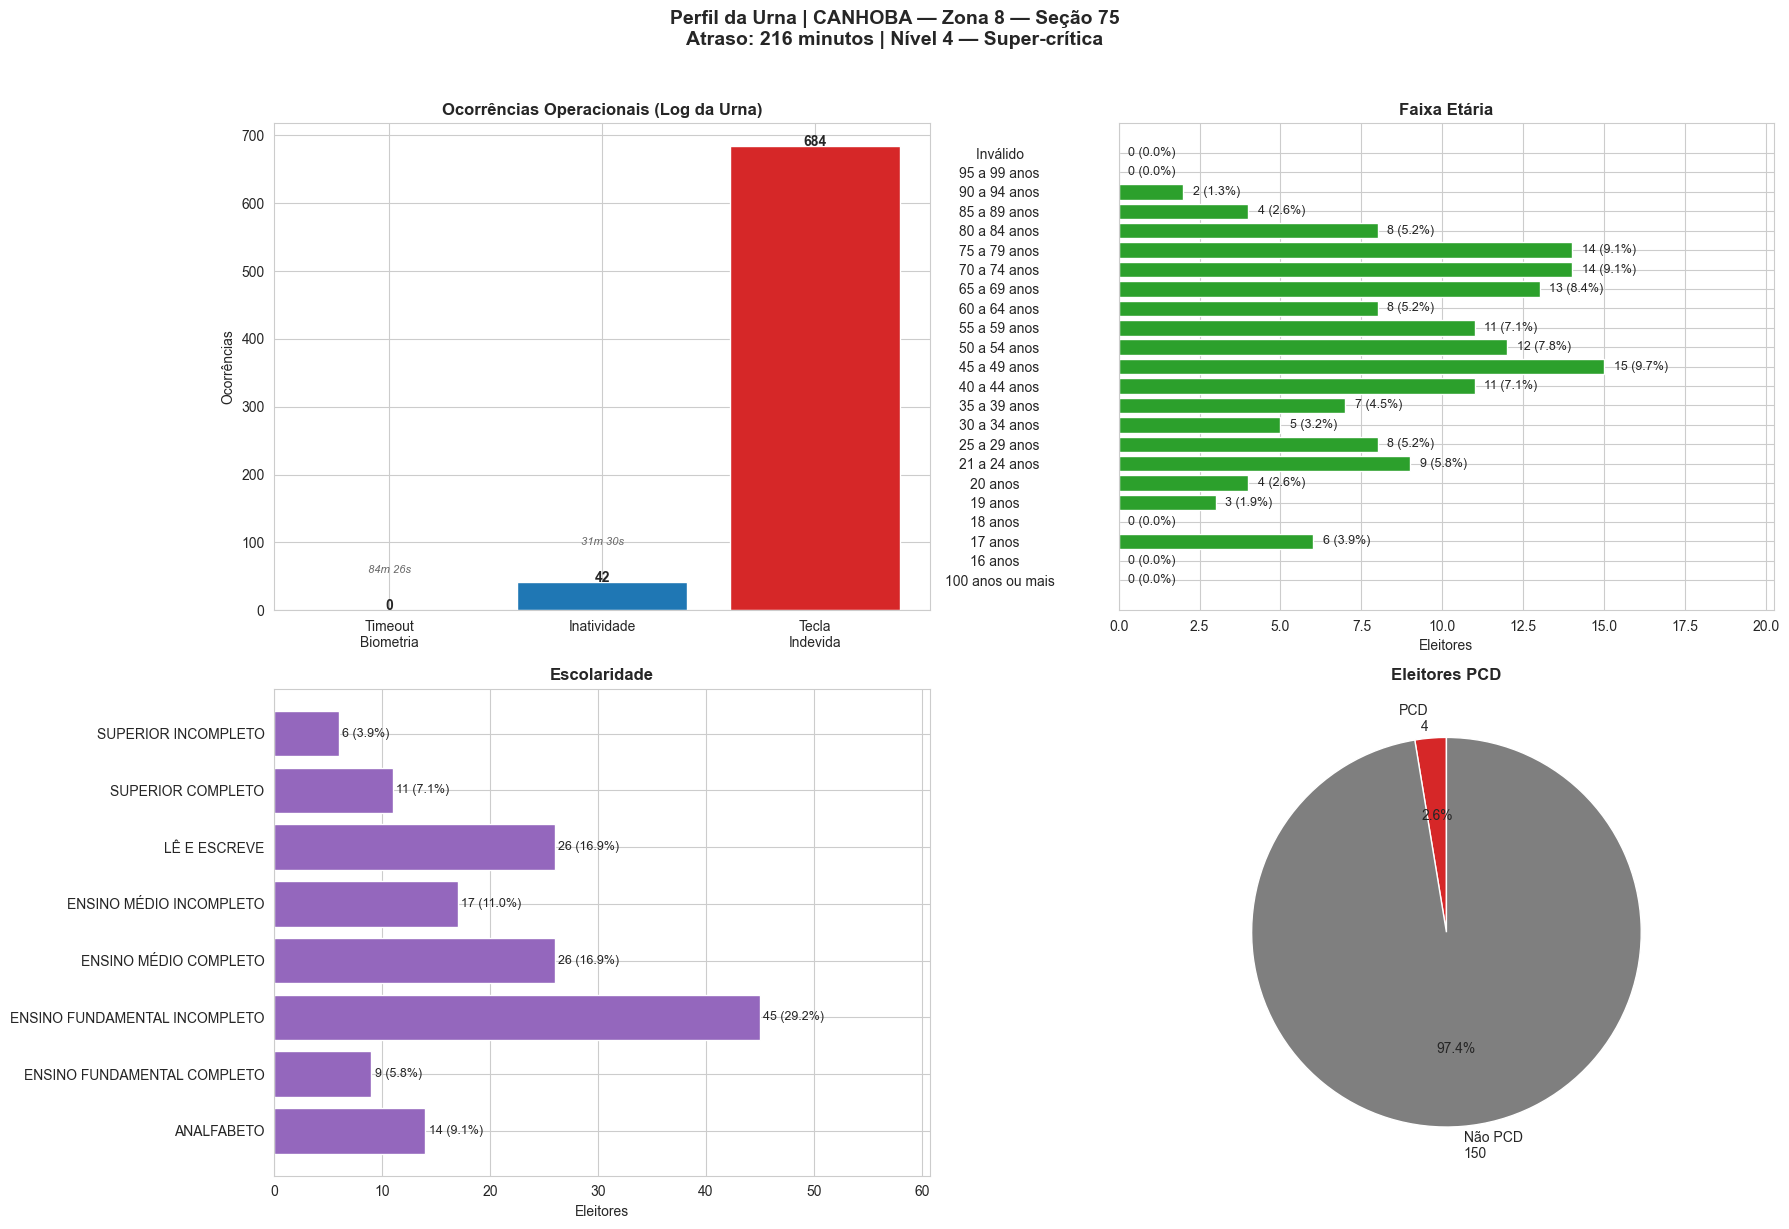


Gerando gráficos: CAPELA | Zona 5 | Seção 54


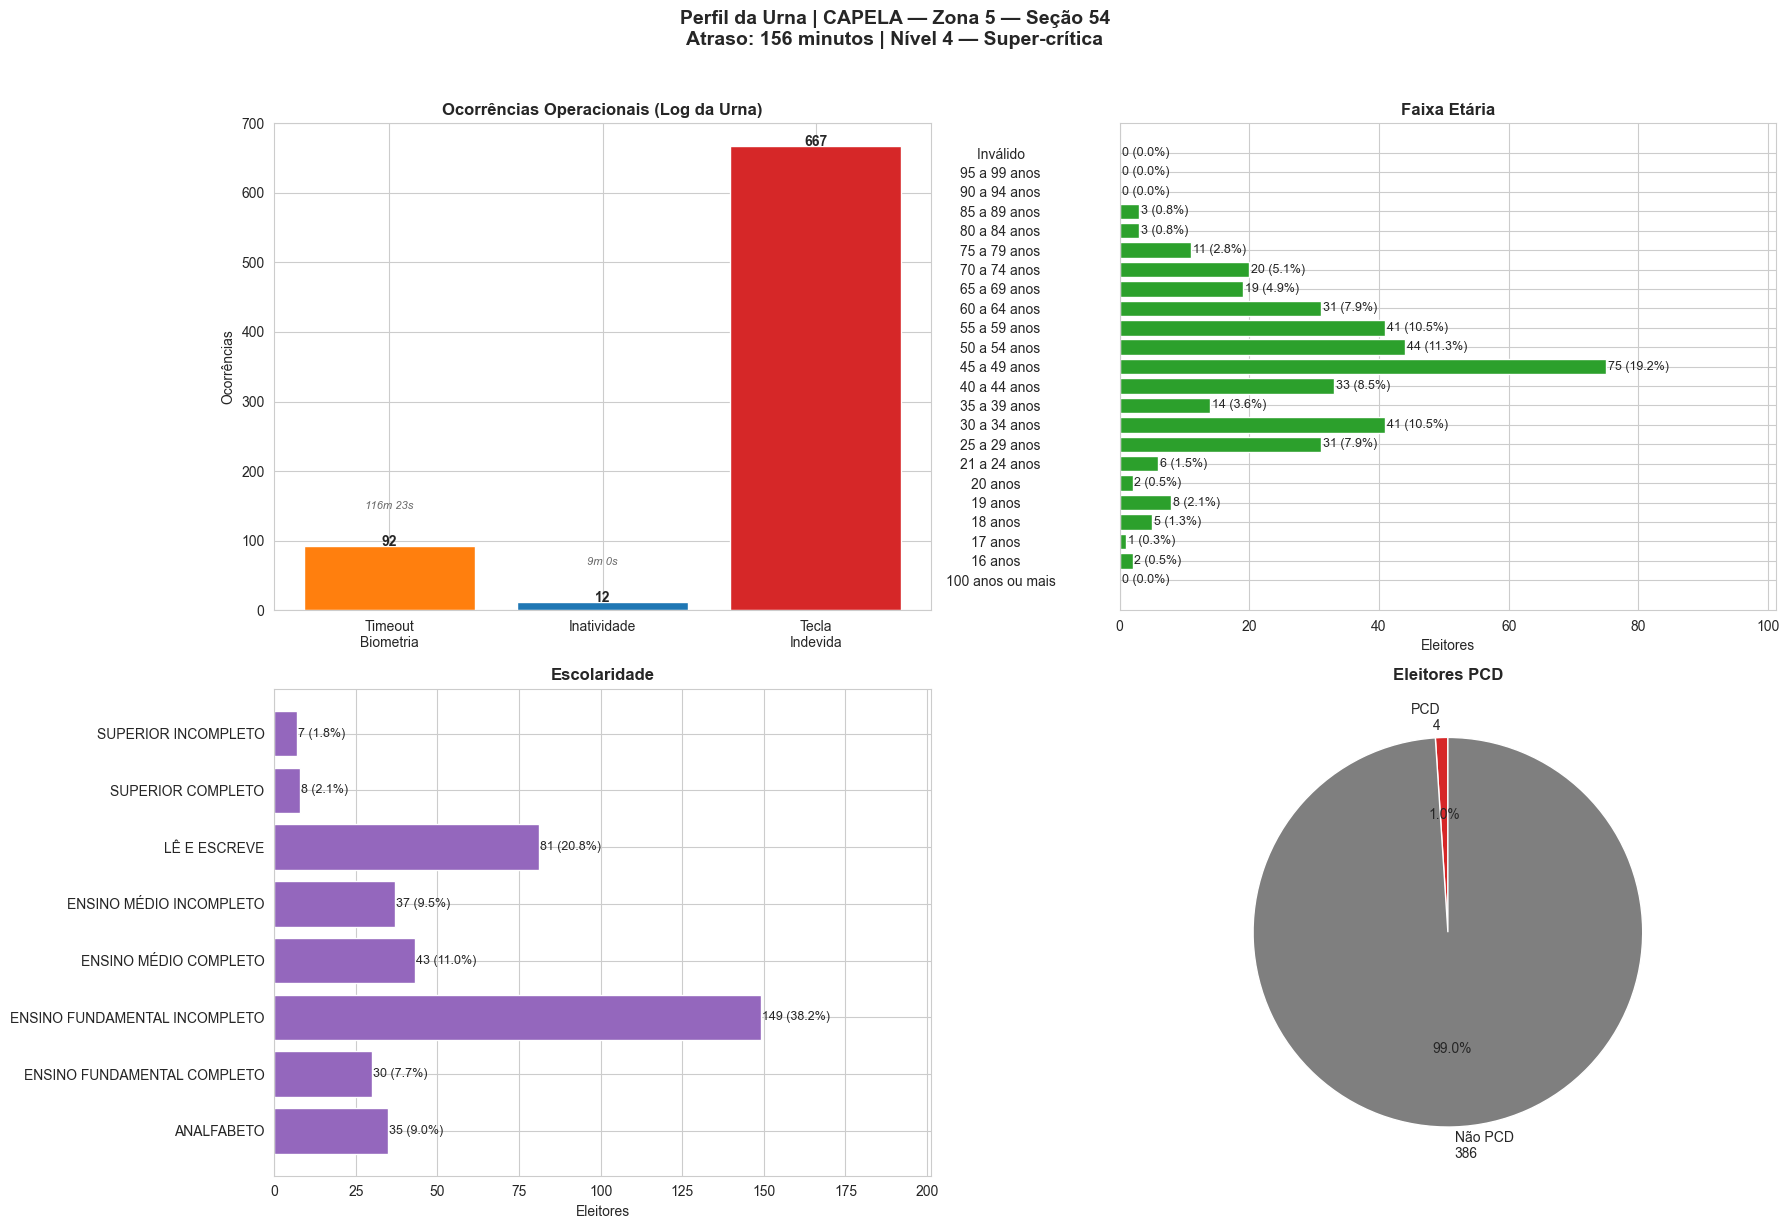


Gerando gráficos: ESTÂNCIA | Zona 6 | Seção 112


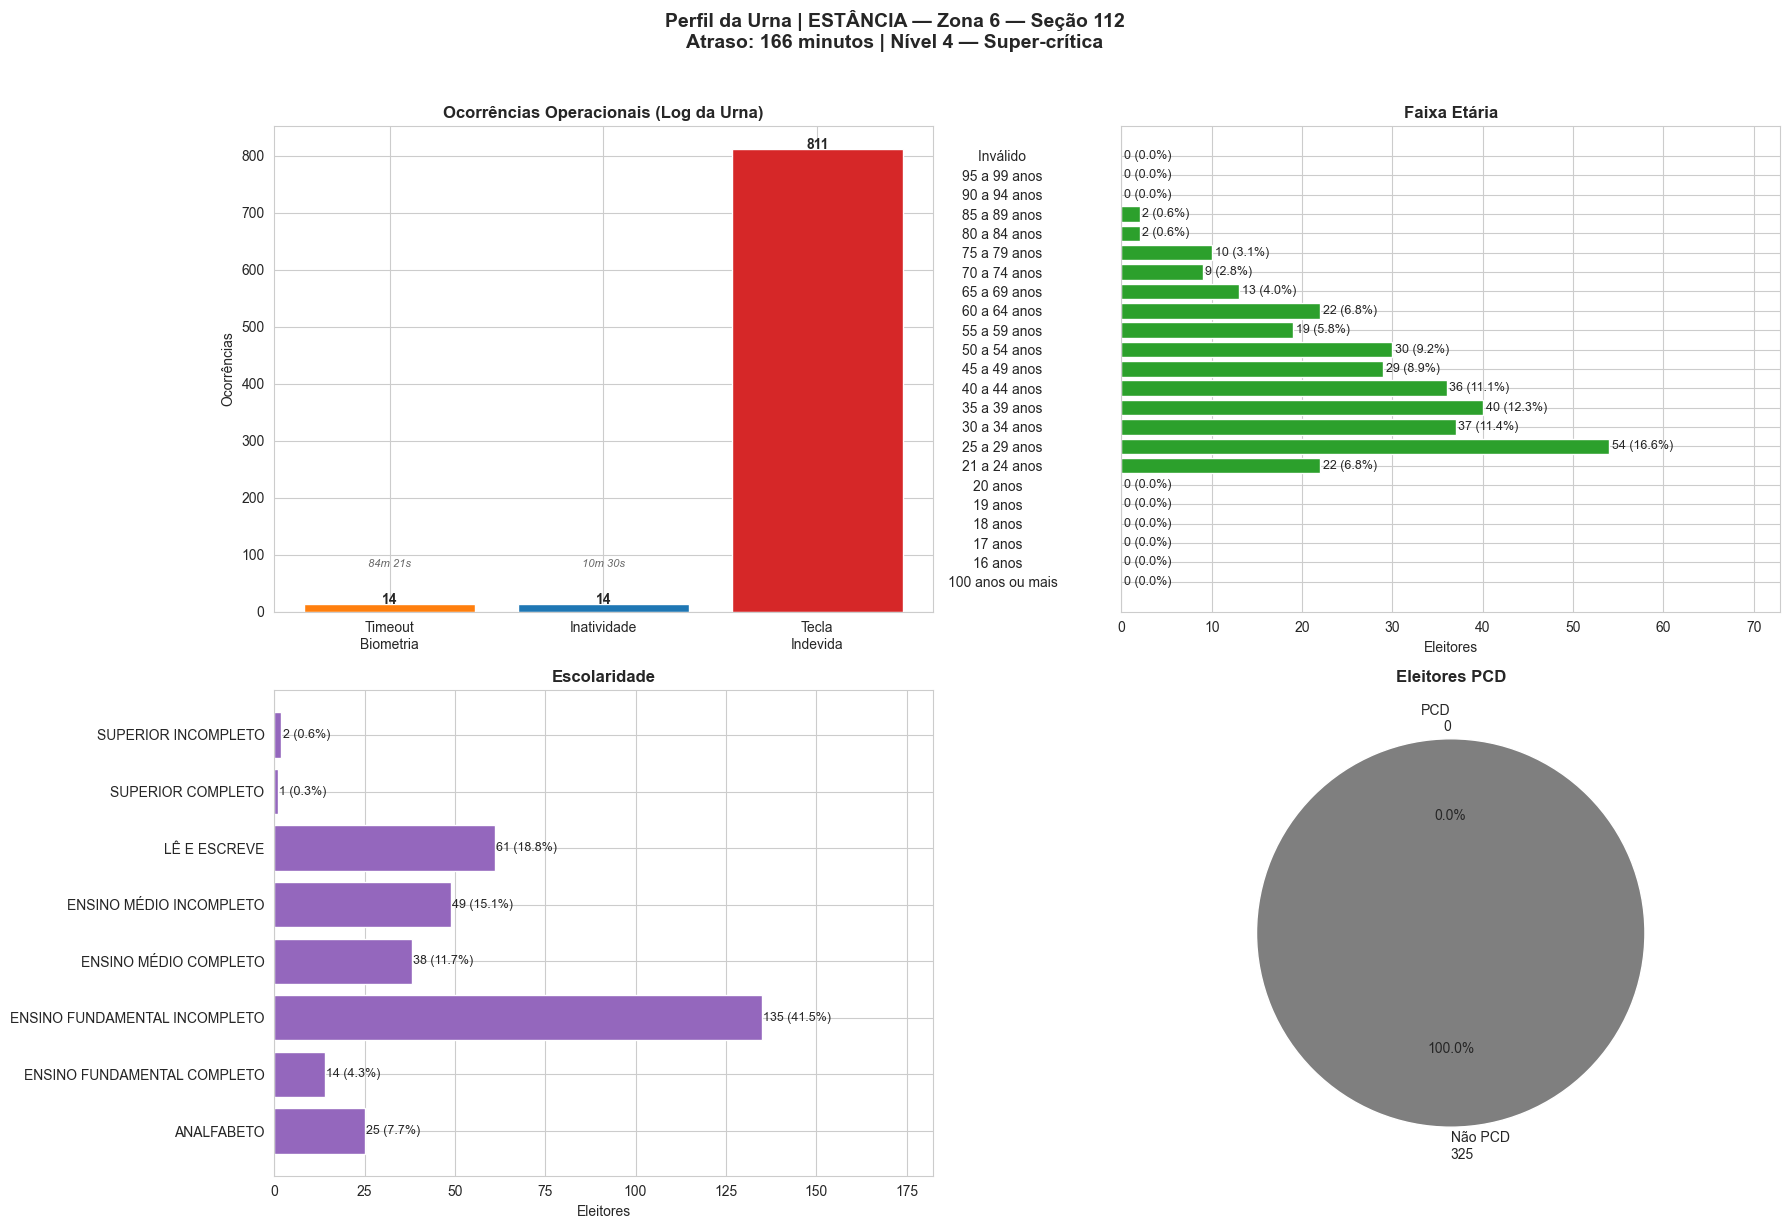


Gerando gráficos: FEIRA NOVA | Zona 16 | Seção 148


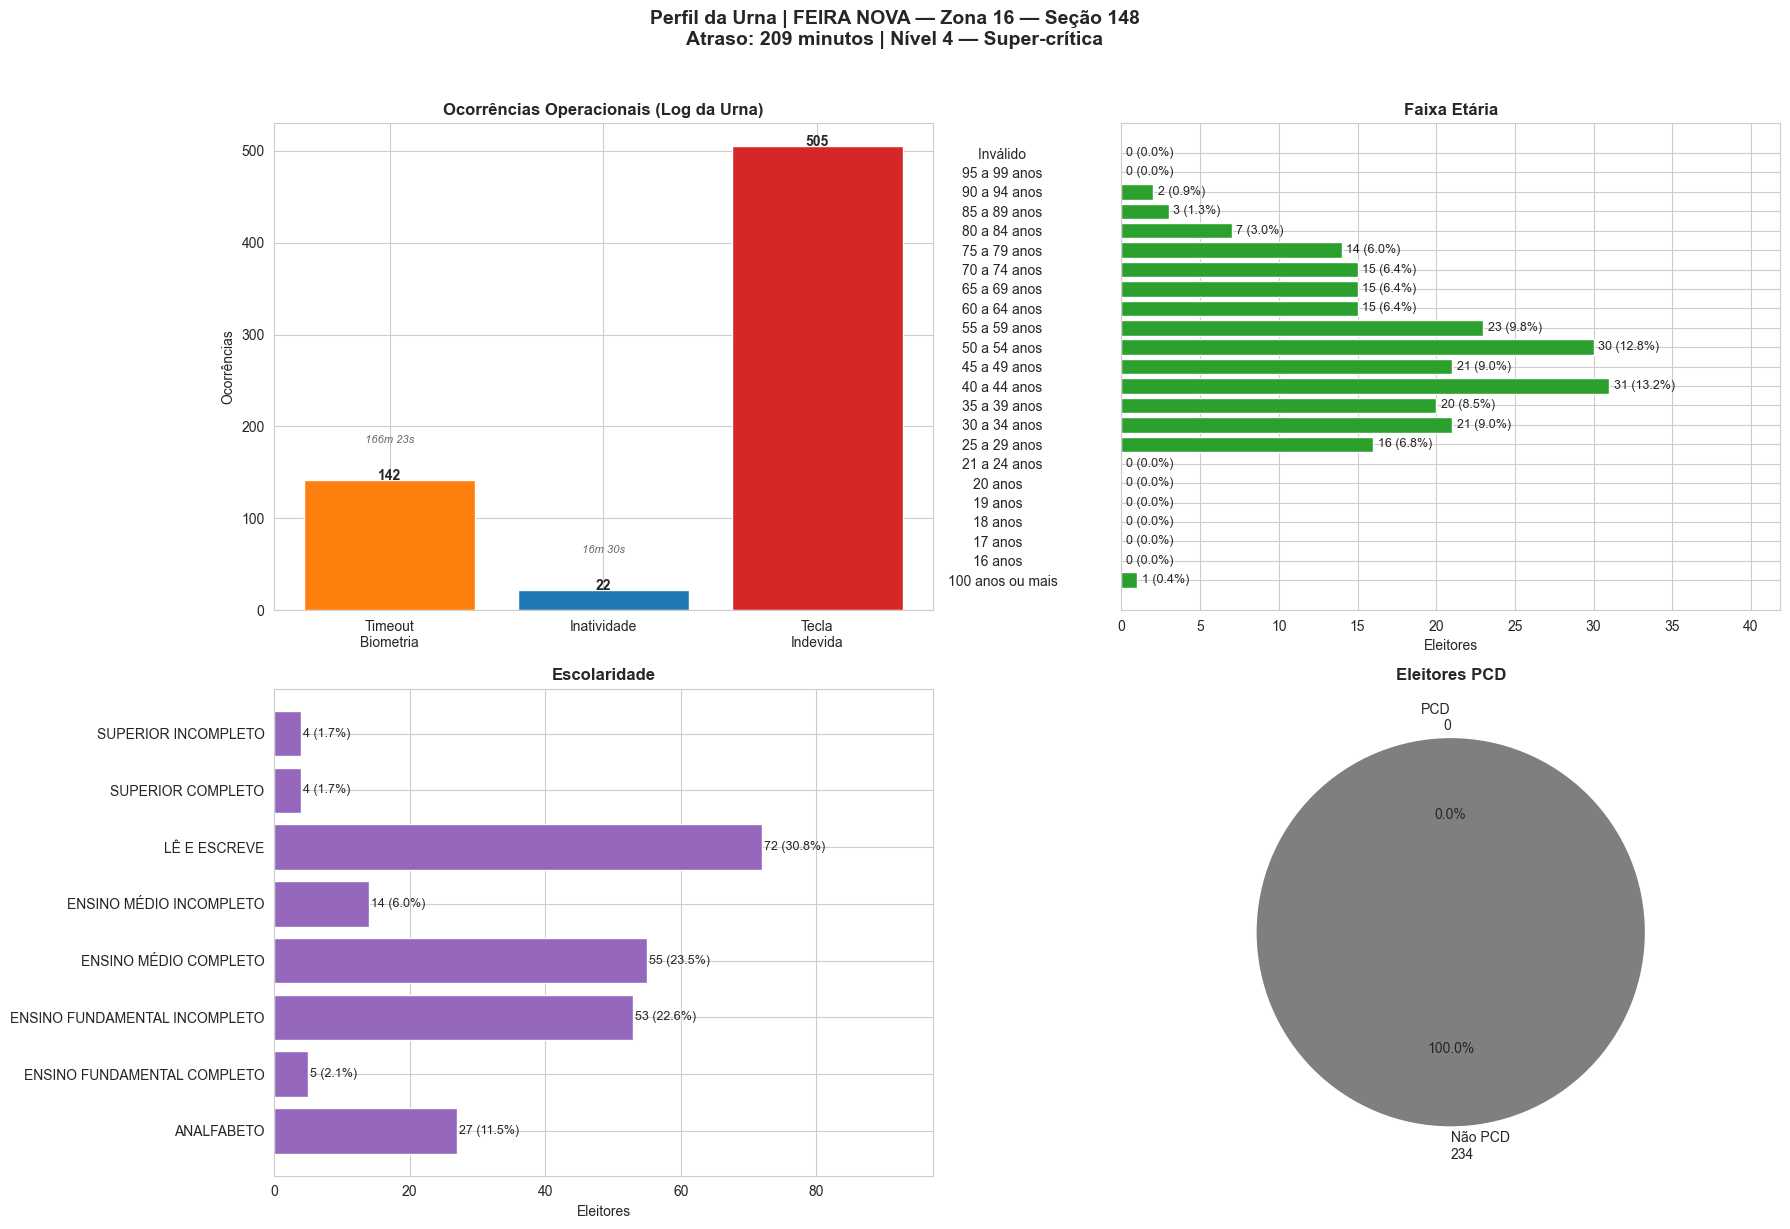


Gerando gráficos: JAPARATUBA | Zona 11 | Seção 91


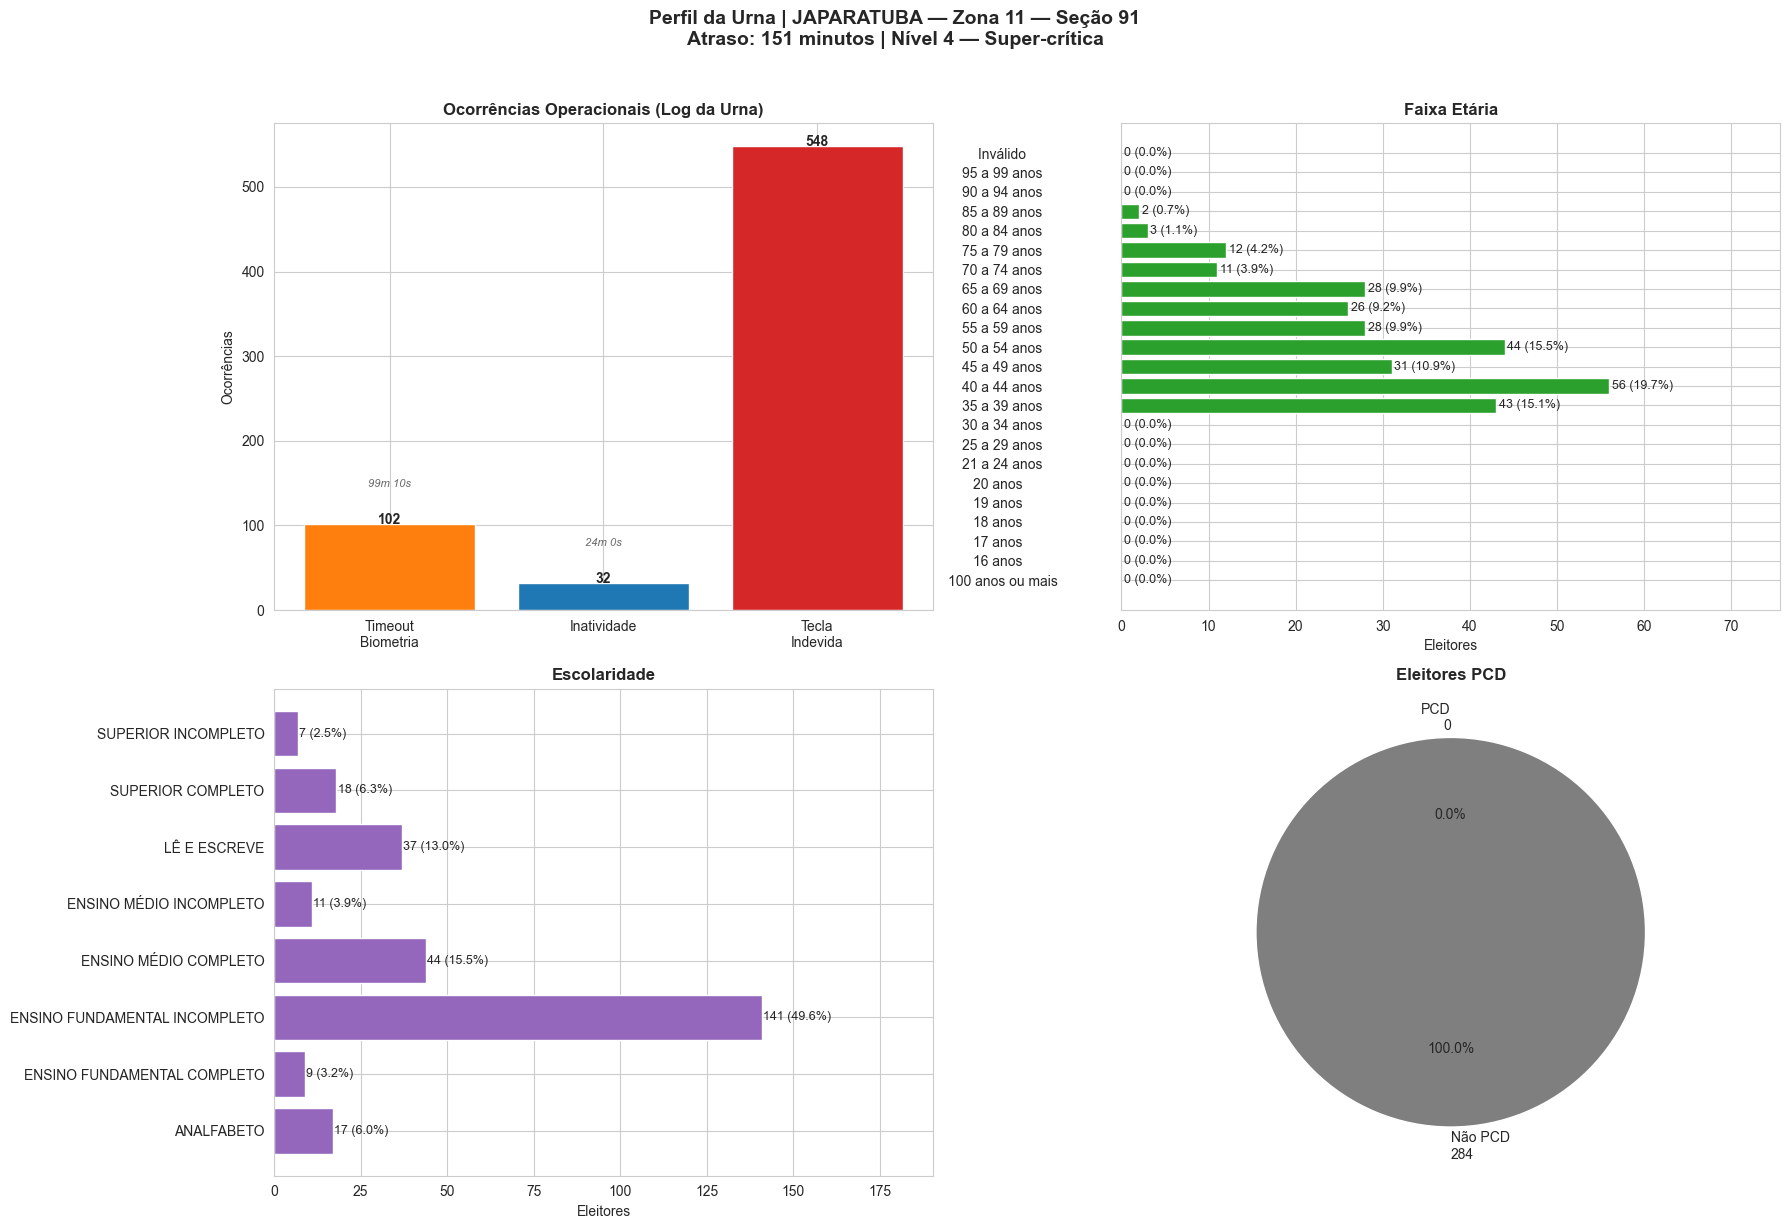


Gerando gráficos: MACAMBIRA | Zona 24 | Seção 67


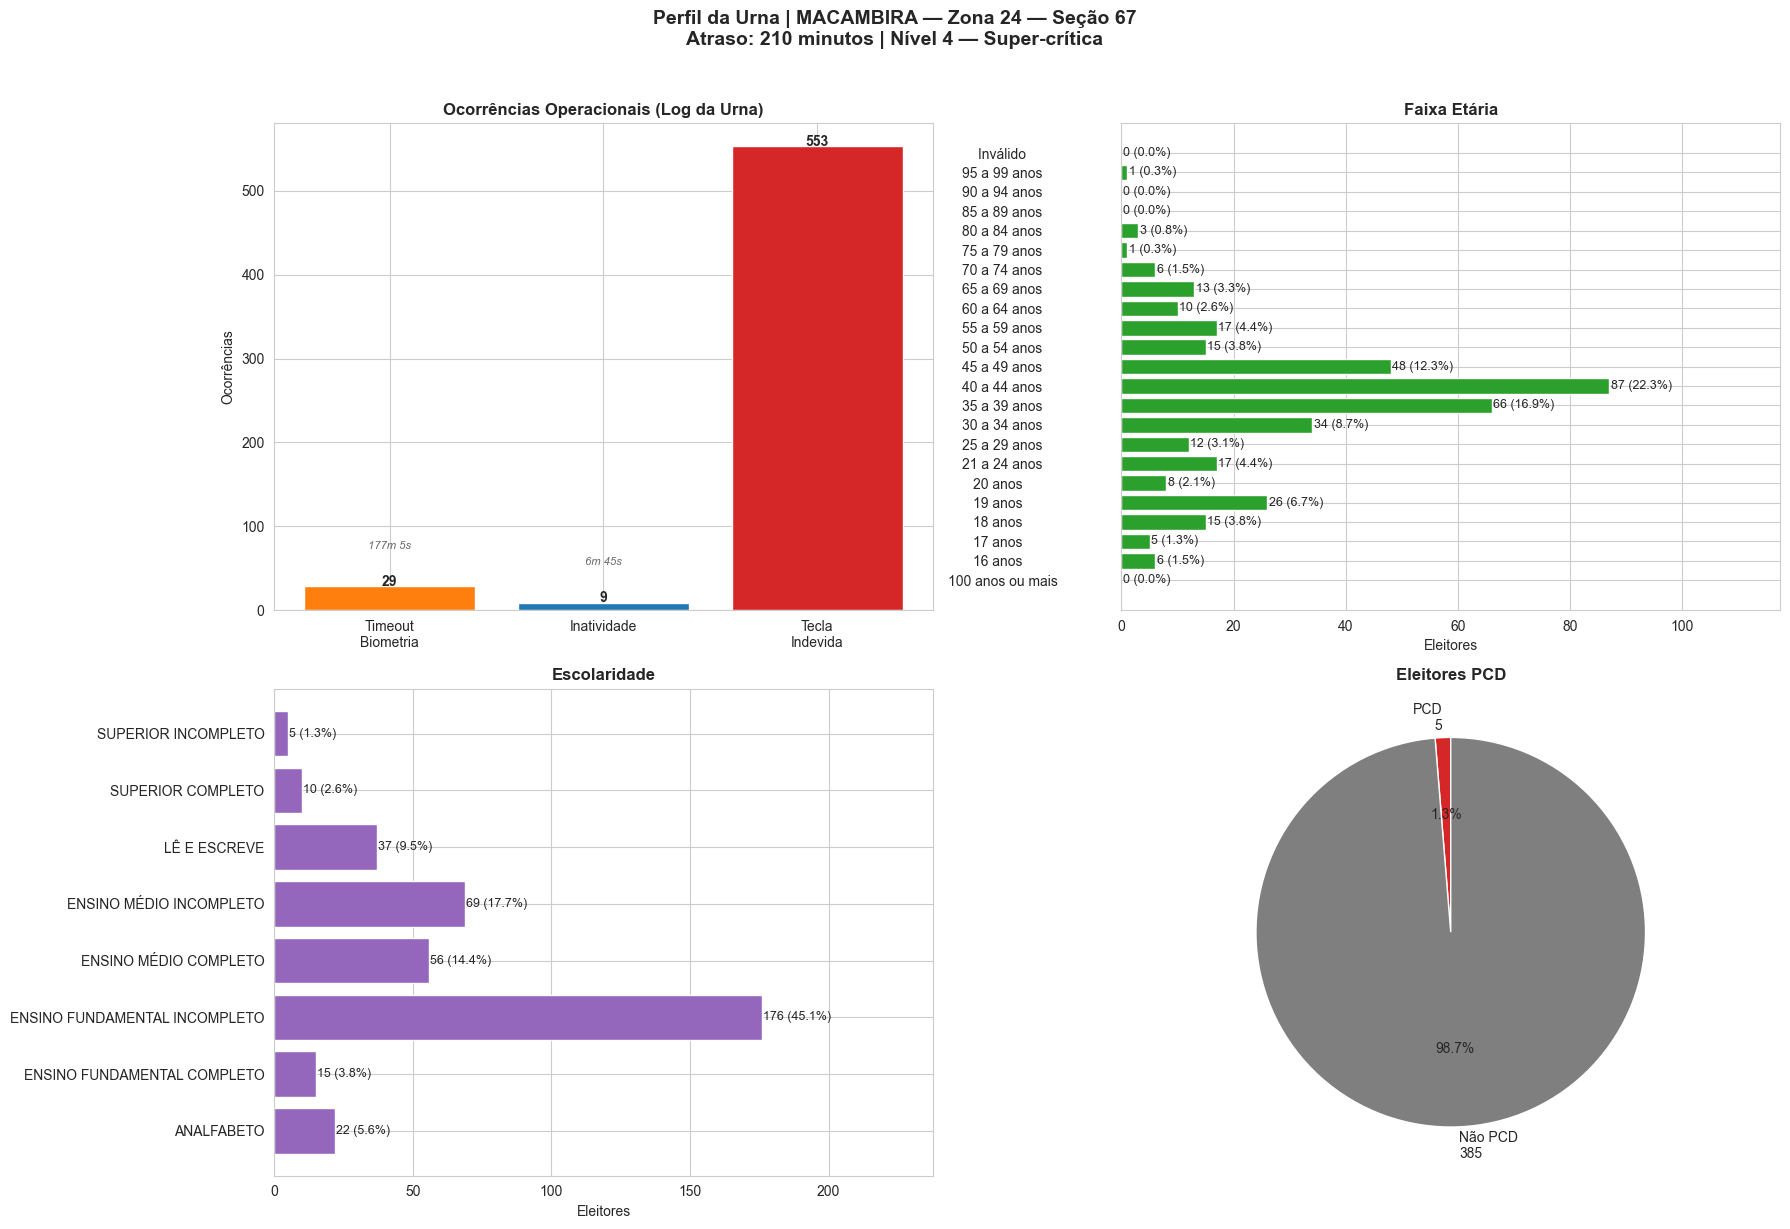


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 76


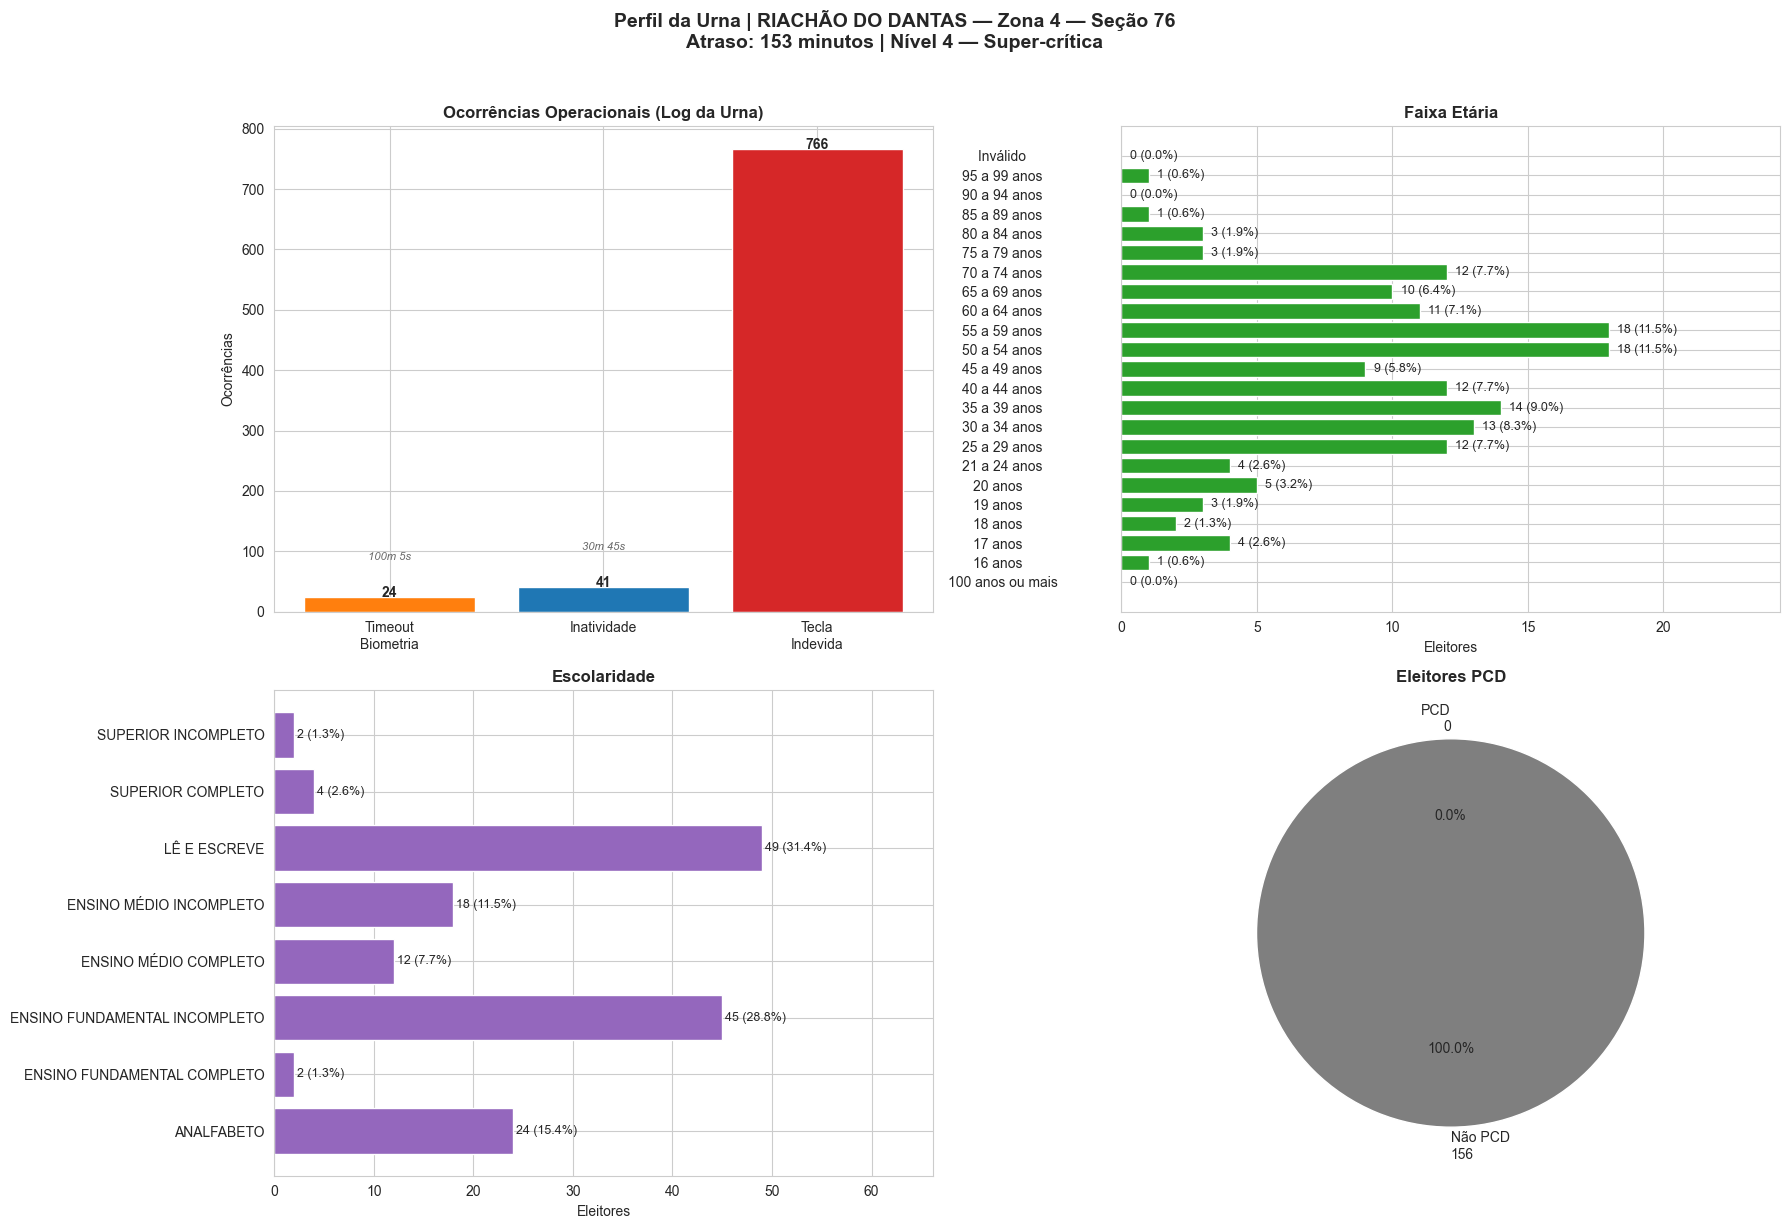


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 111


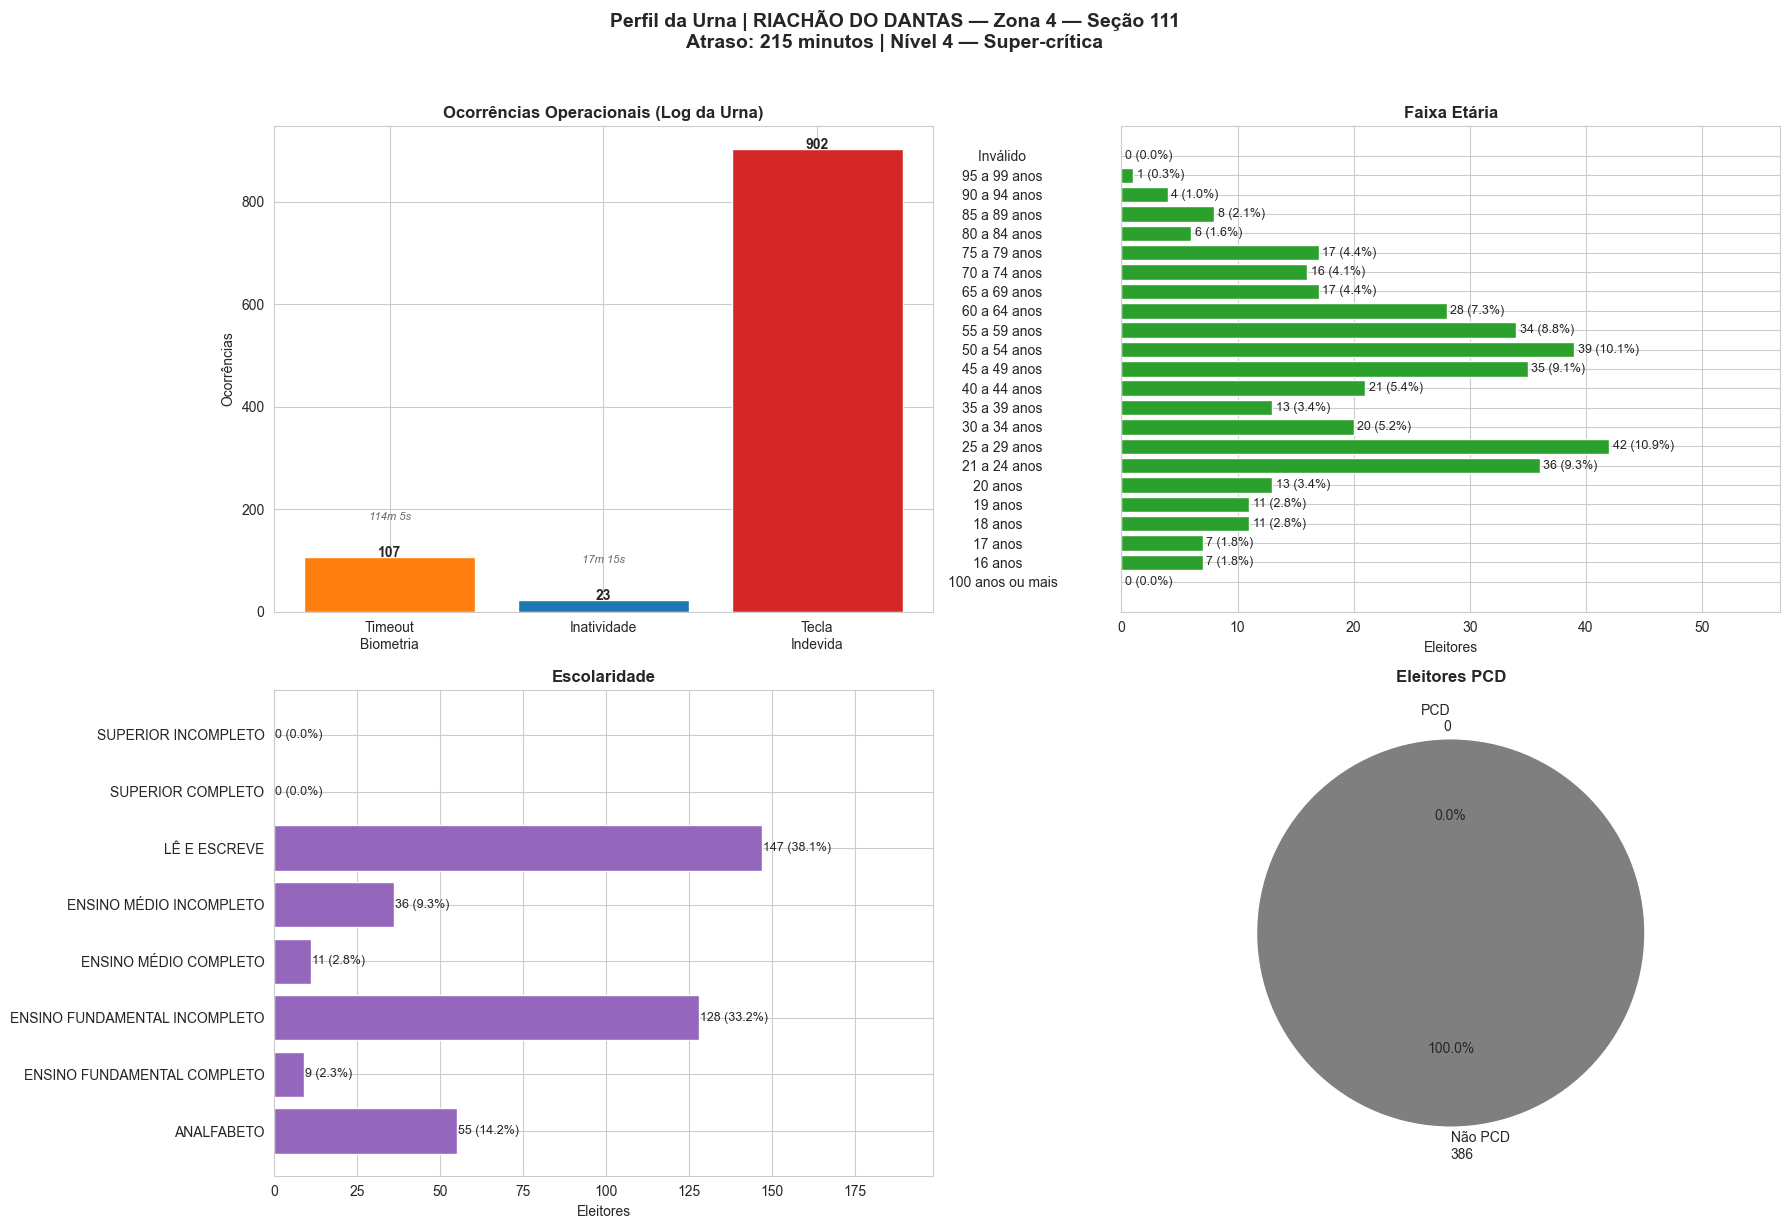


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 134


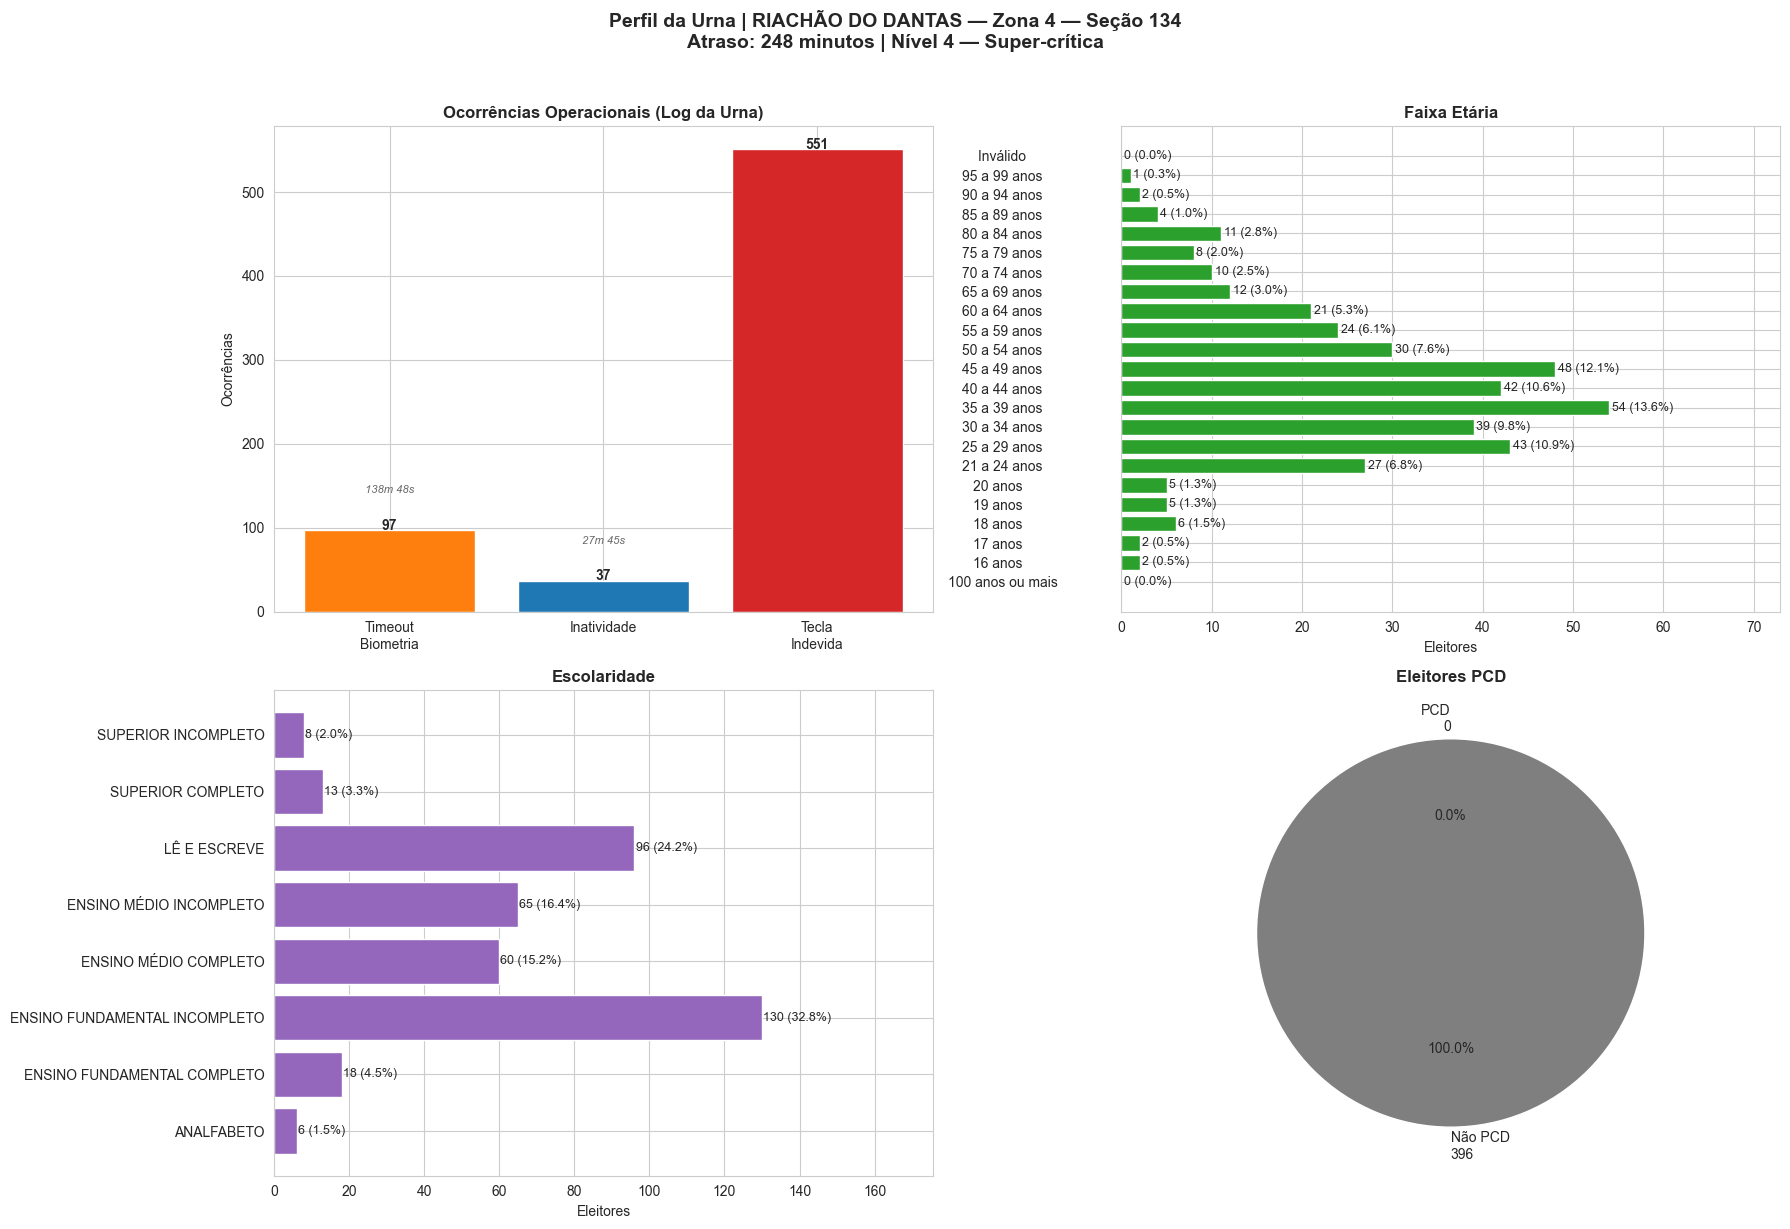


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 137


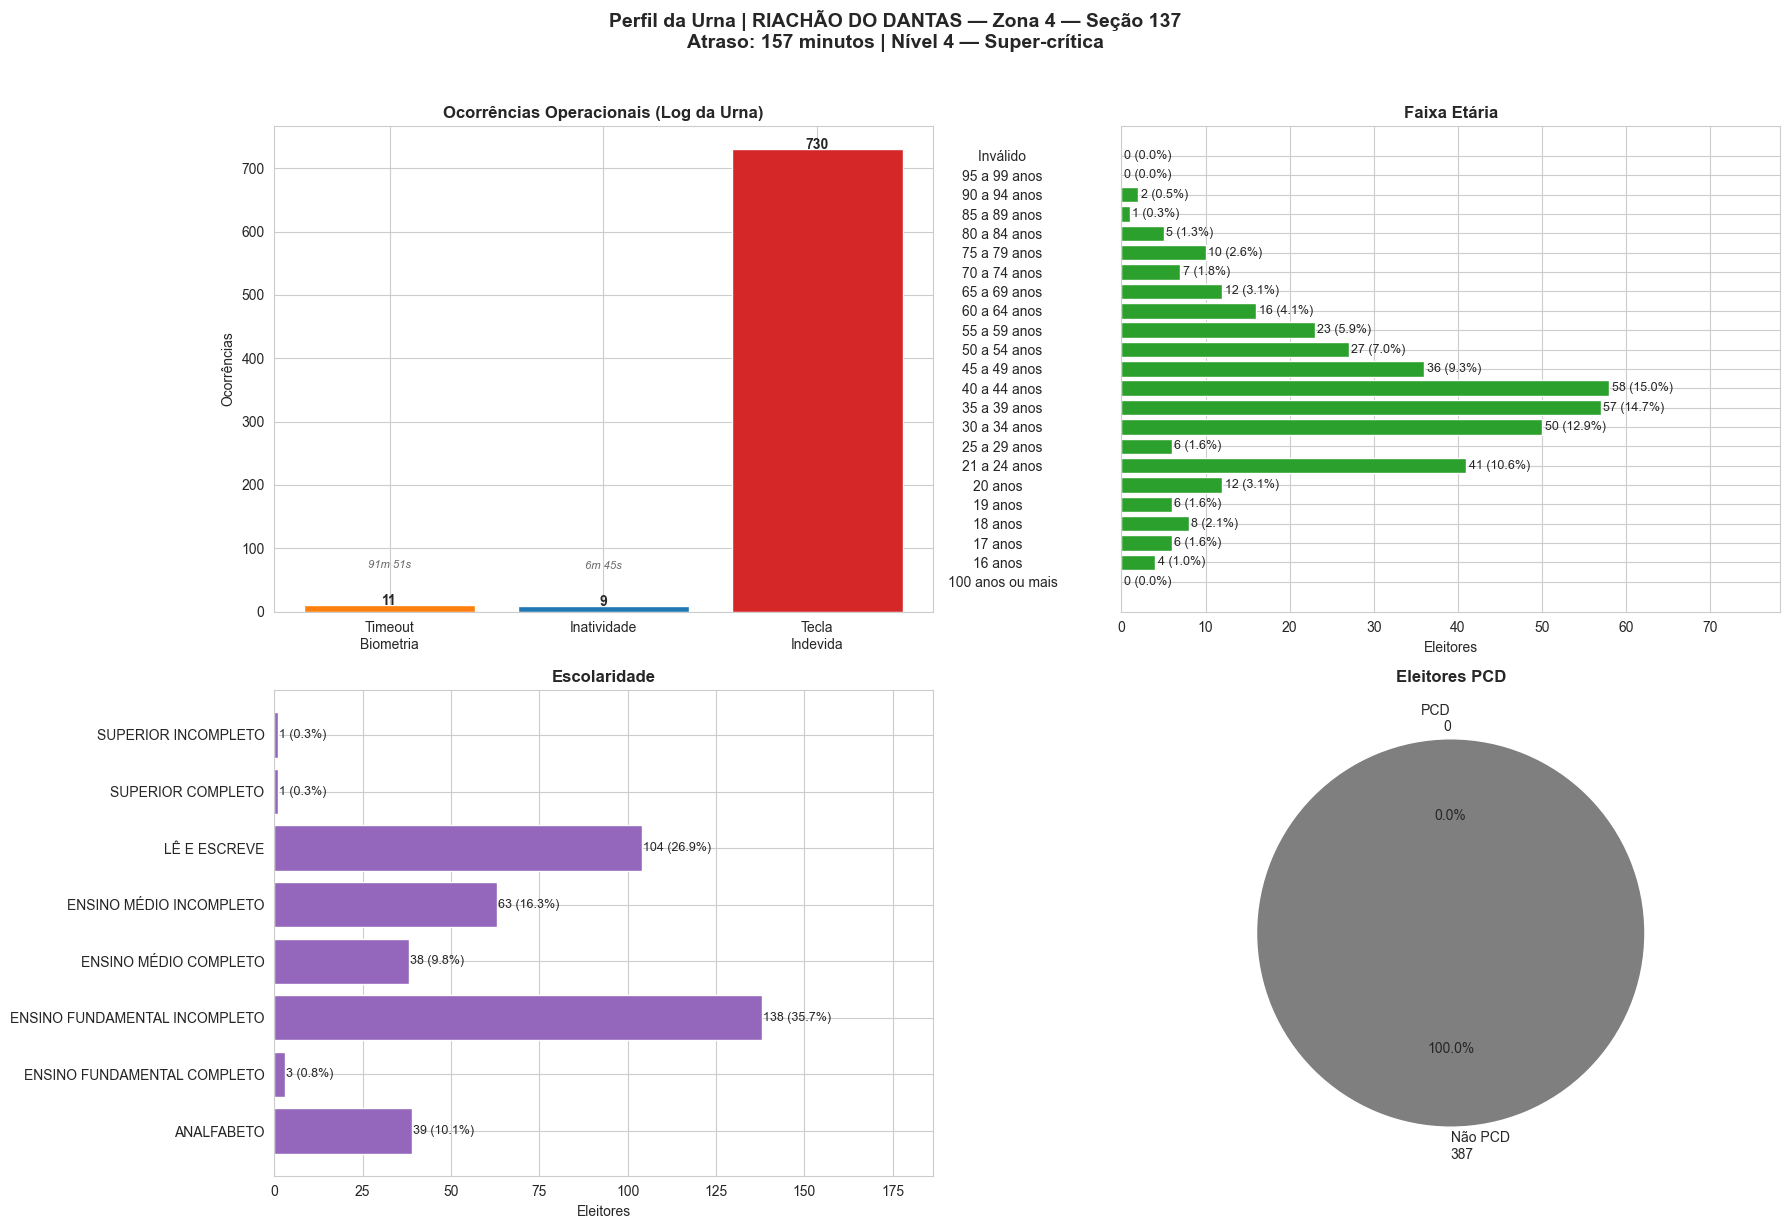


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 138


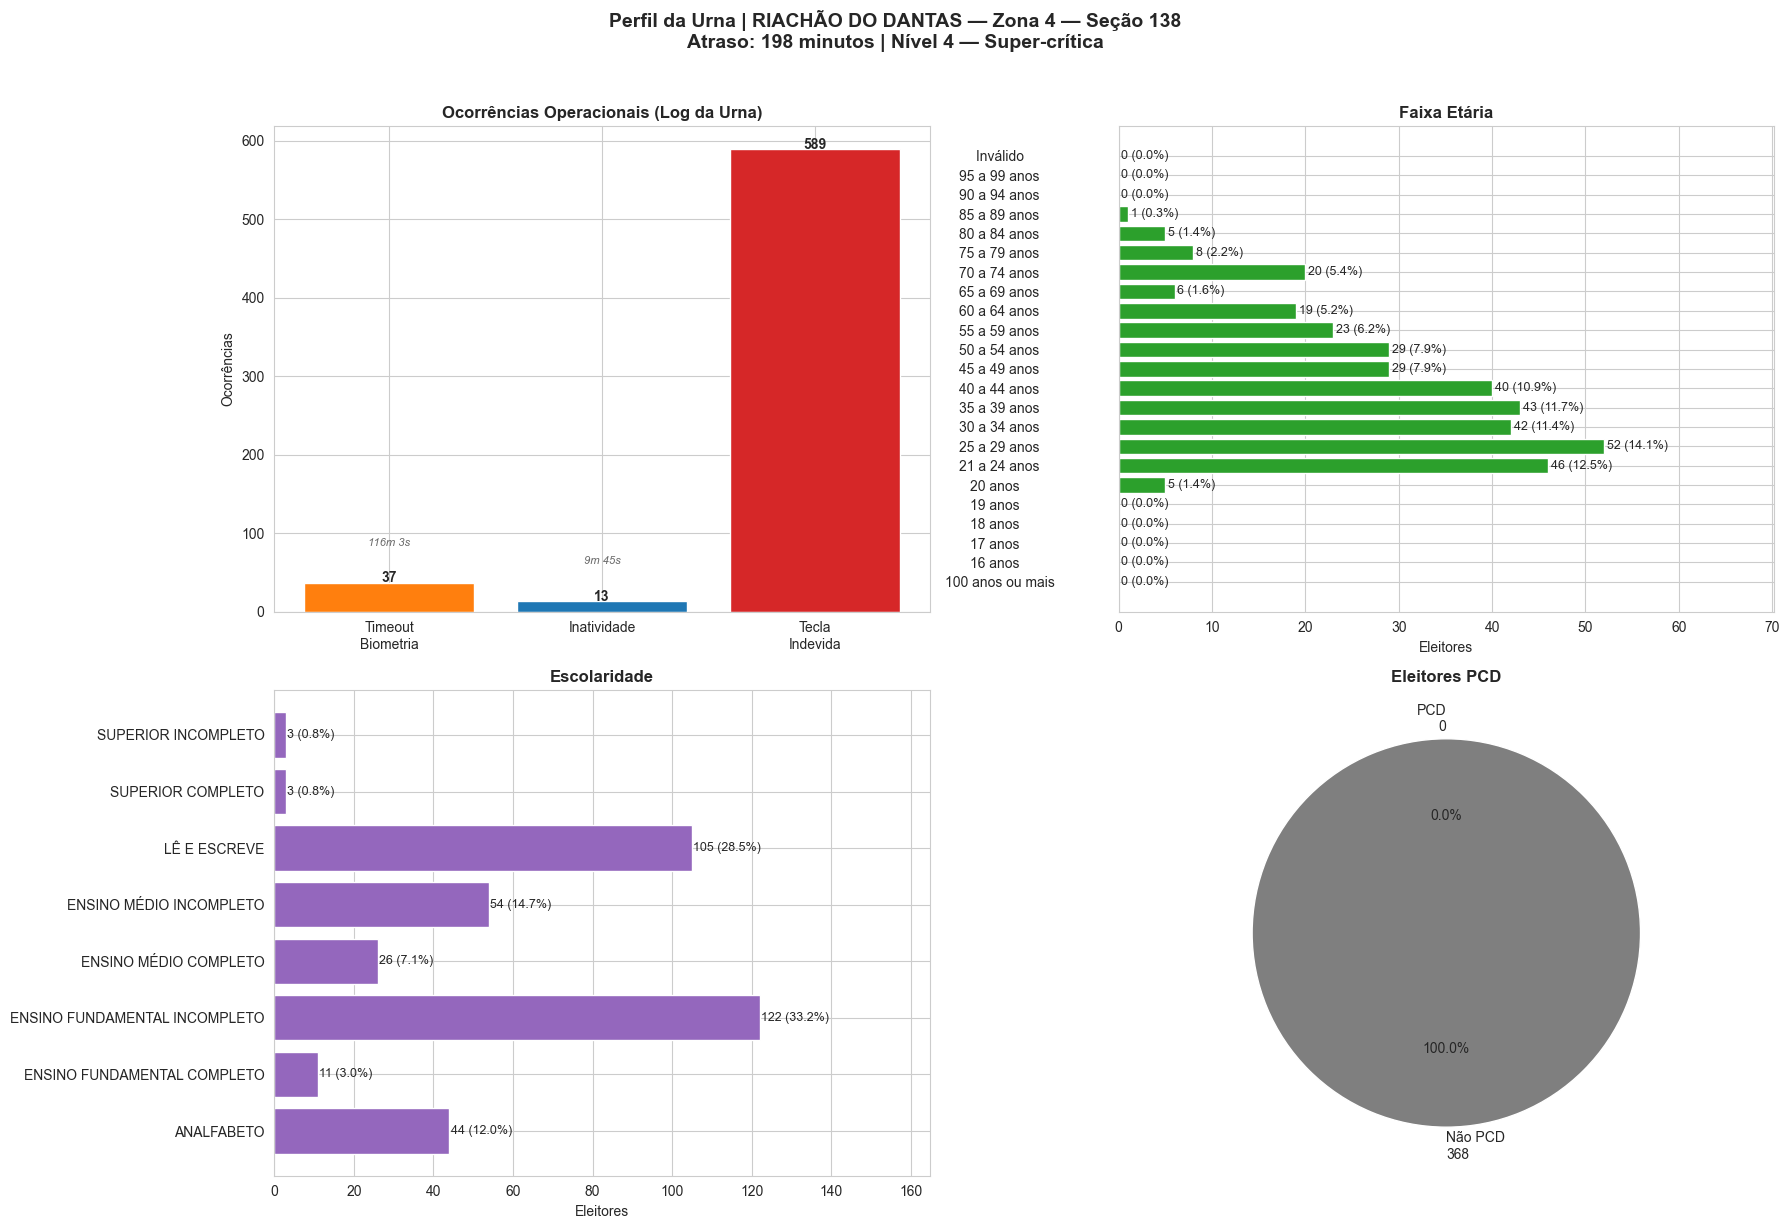


Gerando gráficos: RIACHÃO DO DANTAS | Zona 4 | Seção 151


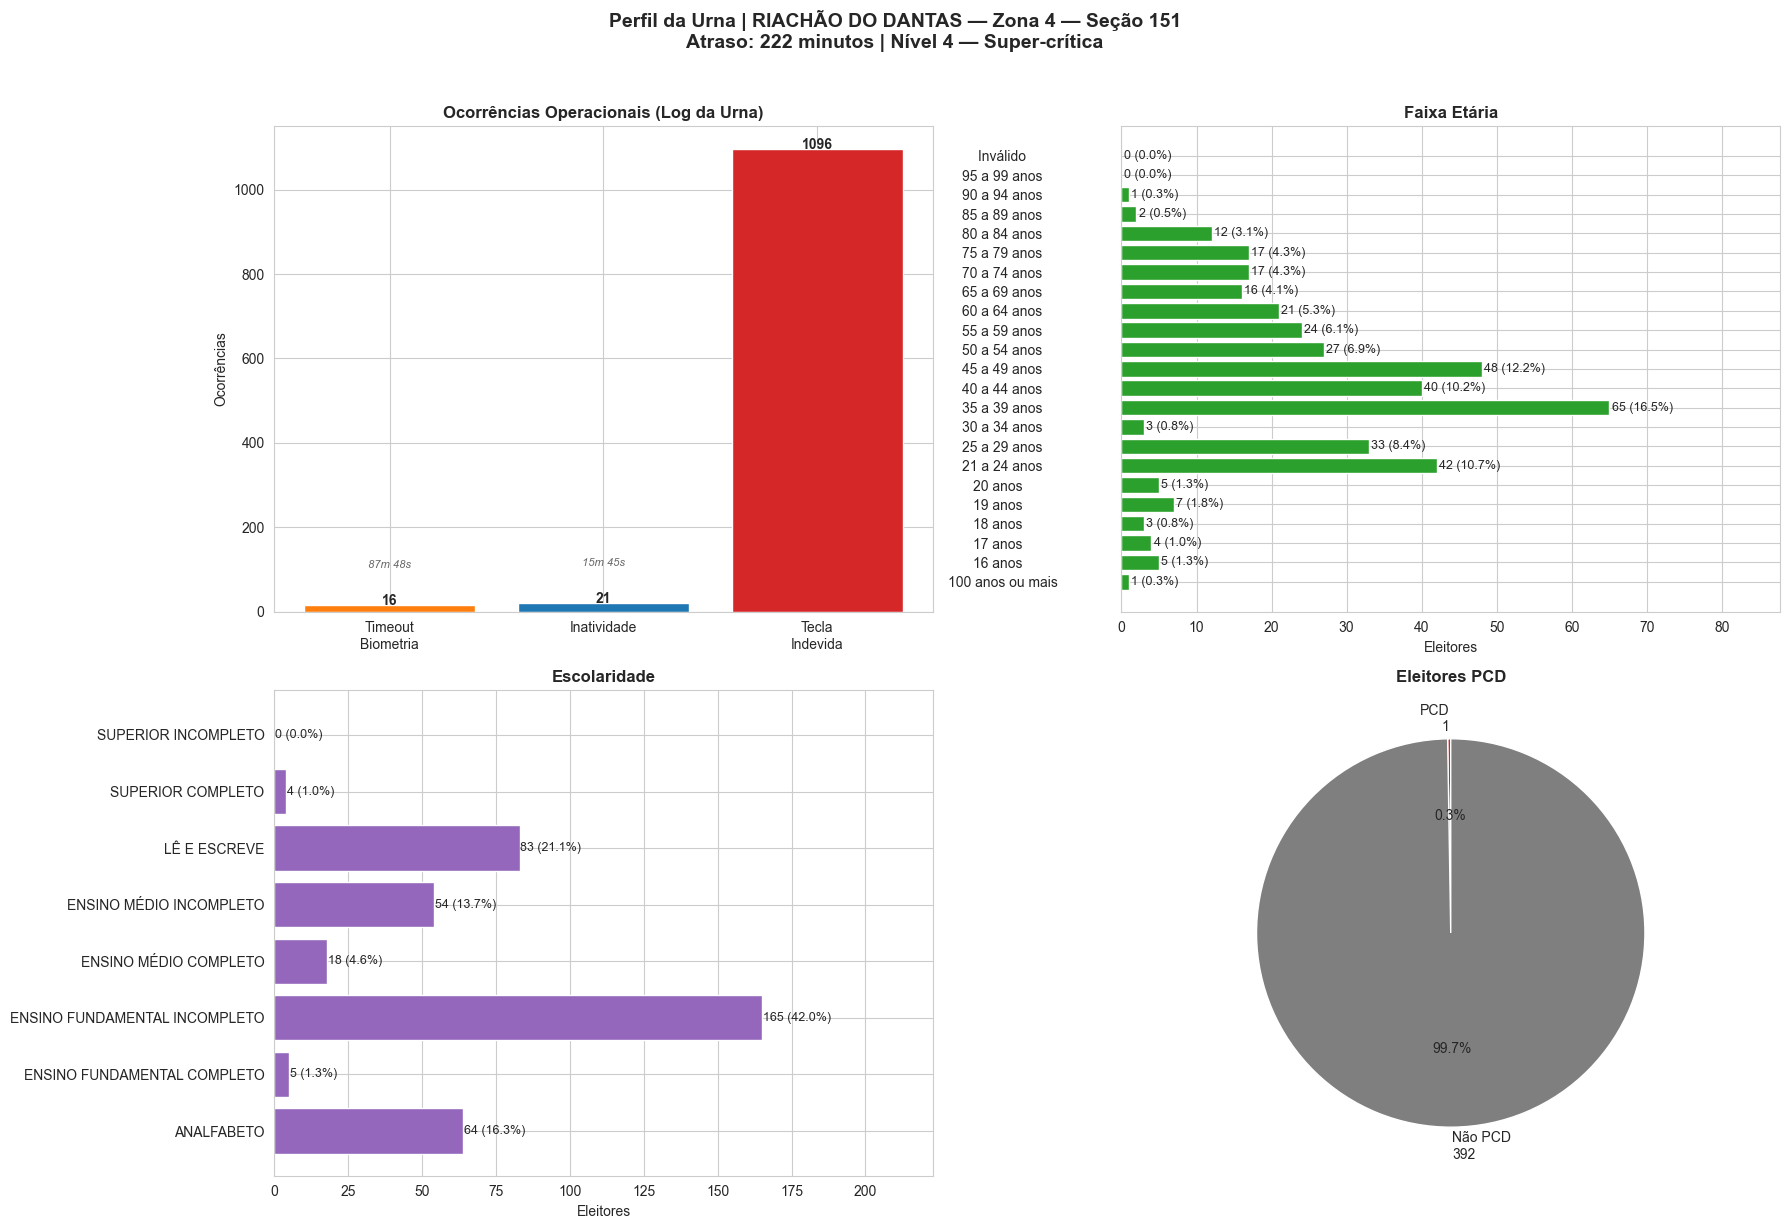


Gerando gráficos: SIRIRI | Zona 5 | Seção 139


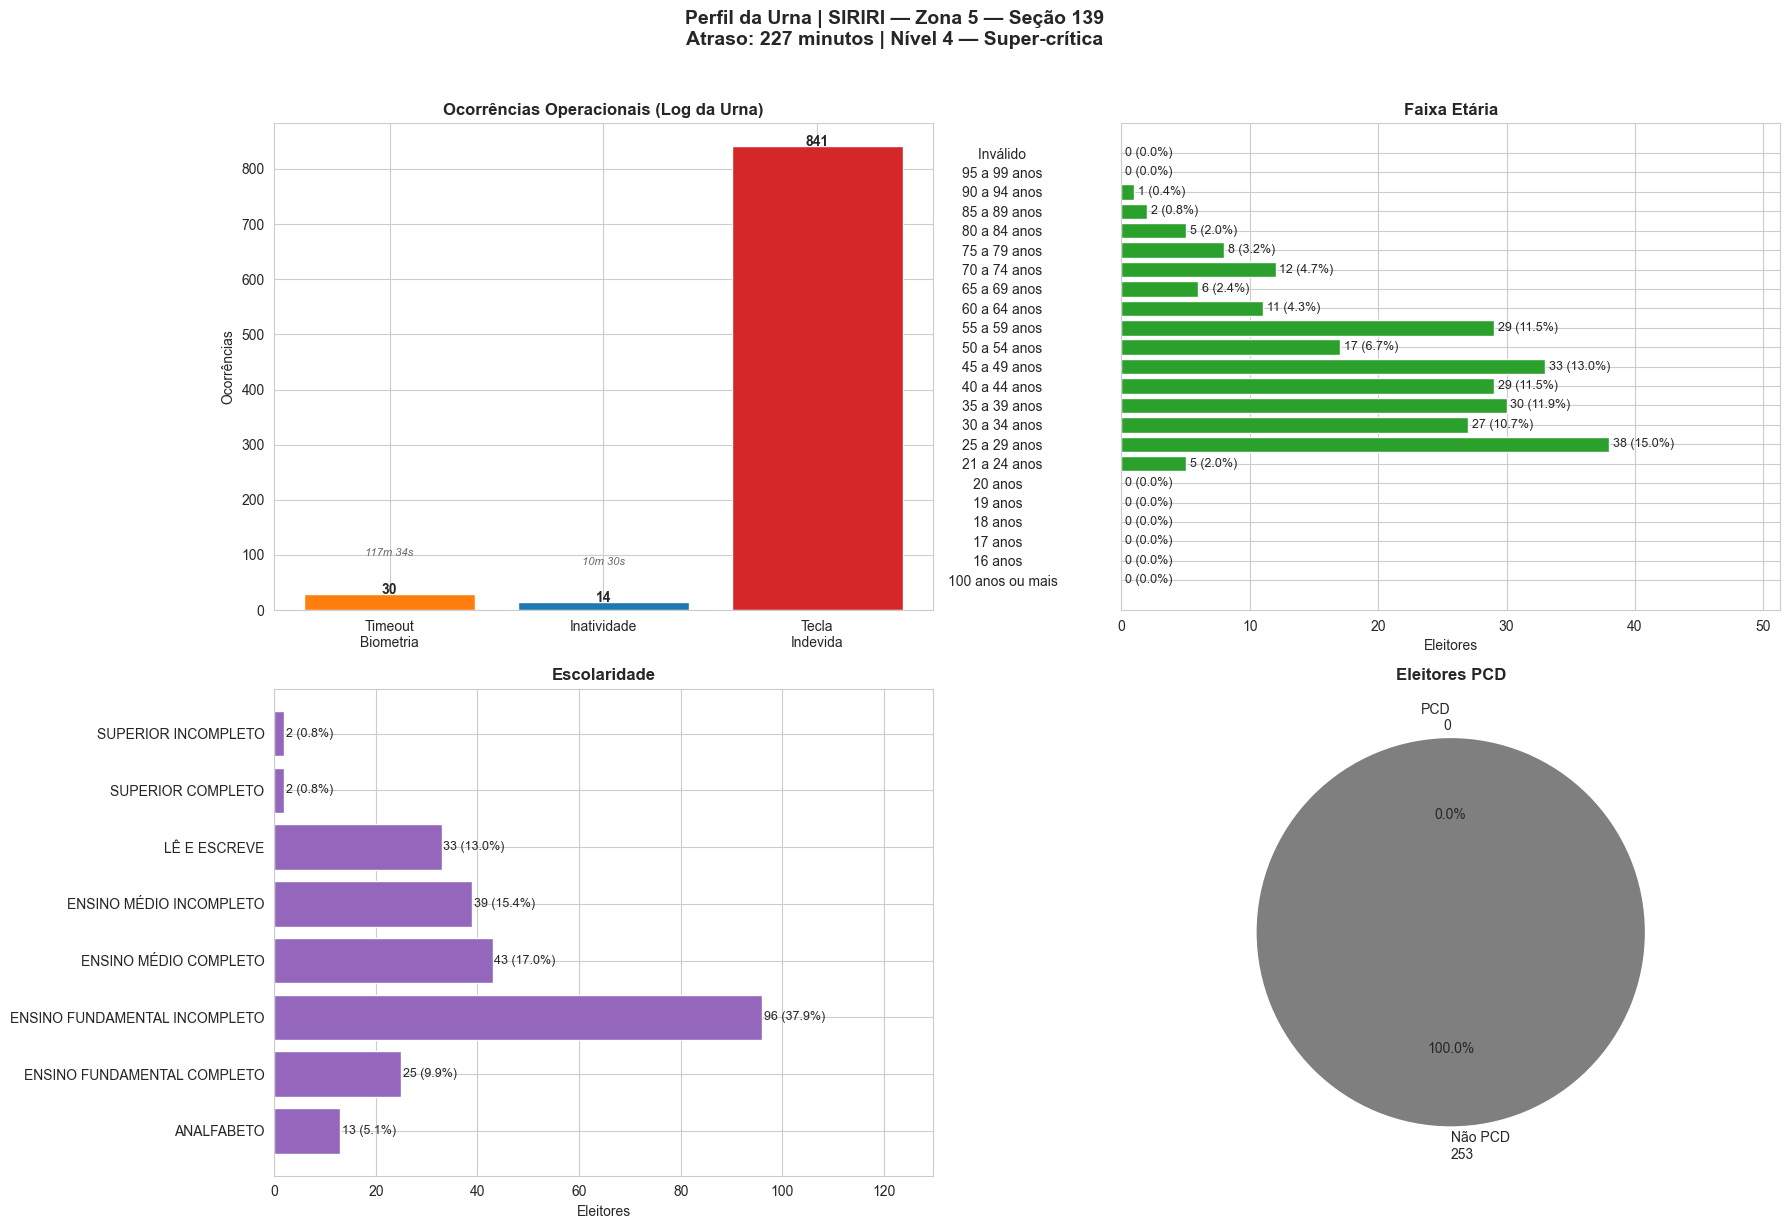


Todos os relatórios gerados!


In [ ]:
urnas_n4 = df_final[df_final['STATUS'] == '4'].copy()
print(f"Total de urnas nível 4: {len(urnas_n4)}")

for _, urna in urnas_n4.iterrows():

    municipio = urna['NM_MUNICIPIO']
    zona      = urna['NR_ZONA']
    secao     = urna['NR_SECAO']
    atraso    = urna['ATRASO_FILA_MINUTOS']

    print(f"\nGerando gráficos: {municipio} | Zona {zona} | Seção {secao}")

    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(
        f'Perfil da Urna | {municipio} — Zona {zona} — Seção {secao}\n'
        f'Atraso: {atraso:.0f} minutos | Nível 4 — Super-crítica',
        fontsize=14, fontweight='bold', y=1.02
    )

    # ----- Gráfico 1: Métricas Operacionais -----

    ax = axes[0, 0]
    metricas = ['TIMEOUT_BIOMETRIA', 'INATIVIDADE', 'TECLA_INDEVIDA']
    labels   = ['Timeout\nBiometria', 'Inatividade', 'Tecla\nIndevida']
    valores  = [urna[m] for m in metricas]
    cores    = ['tab:orange', 'tab:blue', 'tab:red']

    barras = ax.bar(labels, valores, color=cores)
    ax.set_title('Ocorrências Operacionais (Log da Urna)', fontweight='bold')
    ax.set_ylabel('Ocorrências')

    tempo_bio = urna['TPBSEC']
    tempo_inat = urna['TTPISEC']
    tempos = [tempo_bio, tempo_inat, None]  # None para tecla indevida

    for barra, valor, tempo in zip(barras, valores, tempos):
        # Número de ocorrências
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 0.1,
            str(int(valor)),
            ha='center', fontweight='bold'
        )
        # Tempo perdido no topo, apenas para biometria e inatividade
        if tempo is not None:
            minutos = int(tempo) // 60
            segundos = int(tempo) % 60
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_height() + max(valores) * 0.08,
                f'{minutos}m {segundos}s',
                ha='center', fontsize=8, color='dimgray', style='italic'
        )

    # ----- Gráfico 2: Faixa Etária com quantidade e % -----
    ax = axes[0, 1]
    colunas_idade = [c for c in urnas_n4.columns if c.startswith('IDADE_')]
    valores_idade = urna[colunas_idade].values
    labels_idade  = [c.replace('IDADE_', '') for c in colunas_idade]
    total_idade   = valores_idade.sum()

    ax.barh(labels_idade, valores_idade, color='tab:green')
    ax.set_title('Faixa Etária', fontweight='bold')
    ax.set_xlabel('Eleitores')

    # Quantidade e % no final de cada barra
    for i, valor in enumerate(valores_idade):
        pct = (valor / total_idade * 100) if total_idade > 0 else 0
        ax.text(
            valor + 0.3, i,
            f'{int(valor)} ({pct:.1f}%)',
            va='center', fontsize=9
        )
    ax.set_xlim(0, valores_idade.max() * 1.35)

    # ----- Gráfico 3: Escolaridade com quantidade e % -----
    ax = axes[1, 0]
    colunas_esc = [c for c in urnas_n4.columns if c.startswith('ESC_')]
    valores_esc = urna[colunas_esc].values
    labels_esc  = [c.replace('ESC_', '') for c in colunas_esc]
    total_esc   = valores_esc.sum()

    ax.barh(labels_esc, valores_esc, color='tab:purple')
    ax.set_title('Escolaridade', fontweight='bold')
    ax.set_xlabel('Eleitores')

    # Quantidade e % no final de cada barra
    for i, valor in enumerate(valores_esc):
        pct = (valor / total_esc * 100) if total_esc > 0 else 0
        ax.text(
            valor + 0.3, i,
            f'{int(valor)} ({pct:.1f}%)',
            va='center', fontsize=9
        )
    ax.set_xlim(0, valores_esc.max() * 1.35)

    # ----- Gráfico 4: PCD -----
    ax = axes[1, 1]
    total_eleitores = valores_idade.sum()
    pcd     = urna['QTD_PCD']
    nao_pcd = total_eleitores - pcd
    ax.pie(
        [pcd, nao_pcd],
        labels=[f'PCD\n{int(pcd)}', f'Não PCD\n{int(nao_pcd)}'],
        colors=['tab:red', 'tab:gray'],
        autopct='%1.1f%%',
        startangle=90
    )
    ax.set_title('Eleitores PCD', fontweight='bold')

    plt.tight_layout()
    plt.show()

print("\nTodos os relatórios gerados!")